# RepSeq UCB Analysis - MIPT seminar

## Imports

In [2]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import os

from repseq import clonosets as cl
from repseq import io as repseqio
from repseq import clone_filter as clf
from repseq import stats
from repseq import plot as rsplot
from repseq import clustering
from repseq import beta

## WORKING DIR

In [23]:
WORKING_DIR = "/your/working/dir/"

In [4]:
os.makedirs(WORKING_DIR, exist_ok=True)

## Read clonosets

The dataset for this tutorial can be downloaded from here: https://figshare.com/articles/dataset/TCR_repertoire_shaping_of_na_ve_T_cell_subsets_in_human_ontogeny/31452001

In [2]:
clonosets_ucb_dir = "/path/to/ucb/figshare/"

In [6]:
clonosets = cl.find_all_mixcr_clonosets(clonosets_ucb_dir, # <- put path (or a list of paths) to your folder(s) with clonosets
                                        show_offtarget=False, 
                                        offtarget_threshold=0.01
                                       )
clonosets

,sample_id,chain,filename
0,c5_nTreg_TRB_1,TRB,/home/mmyshkin/projects/ucb/fastq_upload/figsh...
1,UCB5_nCD4_TRB_2,TRB,/home/mmyshkin/projects/ucb/fastq_upload/figsh...
2,UCB3_nCD8_TRB_1,TRB,/home/mmyshkin/projects/ucb/fastq_upload/figsh...
3,UCB2_nCD4_TRB_1,TRB,/home/mmyshkin/projects/ucb/fastq_upload/figsh...
4,UCB6_nTreg_TRB_1,TRB,/home/mmyshkin/projects/ucb/fastq_upload/figsh...
...,...,...,...
82,UCB5_nCD8_TRB_1,TRB,/home/mmyshkin/projects/ucb/fastq_upload/figsh...
83,a5_nTreg_TRB_1,TRB,/home/mmyshkin/projects/ucb/fastq_upload/figsh...
84,a3_nTreg_TRB_1,TRB,/home/mmyshkin/projects/ucb/fastq_upload/figsh...
85,o6_nTreg_TRB_1,TRB,/home/mmyshkin/projects/ucb/fastq_upload/figsh...


The dataset also contains metadata table, which can read as a pandas DataFrame

## Create metadata

In [7]:
# Define the custom ordered type
exp_group_order = CategoricalDtype(categories=['preterm', 'term', 'late', 'children', 'adults', 'older_adults'], ordered=True)
subset_order = CategoricalDtype(categories=["nCD4", "nTreg", "nCD8"], ordered=True)

metadata = pd.read_csv(os.path.join(clonosets_ucb_dir, "ucb_figshare_TRB_metadata.csv"))[["sample_id", "experimental_group", "donor_id", "subset"]]
metadata["experimental_group"] = metadata["experimental_group"].astype(exp_group_order)
metadata["subset"] = metadata["subset"].astype(subset_order)
metadata["source"] = metadata["experimental_group"].apply(lambda x: "UCB" if x in ['preterm', 'term', 'late'] else "PB")
# metadata["sample_id"] = metadata["sample_id"].apply(lambda x: x.split("_TRB")[0])
metadata.tail()

,sample_id,experimental_group,donor_id,subset,source
82,a6_nCD8_TRB_1,adults,a6,nCD8,PB
83,a4_nCD8_TRB_1,adults,a4,nCD8,PB
84,a12_nCD8_TRB_1,adults,a12,nCD8,PB
85,a14_nTreg_TRB_1,adults,a14,nTreg,PB
86,a16_nTreg_TRB_1,adults,a16,nTreg,PB


## Subset clonosets

In [8]:
clonosets_treg = clonosets.merge(metadata).query("subset == 'nTreg'").reset_index(drop=True)
clonosets_treg

,sample_id,chain,filename,experimental_group,donor_id,subset,source
0,c5_nTreg_TRB_1,TRB,/home/mmyshkin/projects/ucb/fastq_upload/figsh...,children,c5,nTreg,PB
1,UCB6_nTreg_TRB_1,TRB,/home/mmyshkin/projects/ucb/fastq_upload/figsh...,term,UCB6,nTreg,UCB
2,o1_nTreg_TRB_1,TRB,/home/mmyshkin/projects/ucb/fastq_upload/figsh...,older_adults,o1,nTreg,PB
3,a1_nTreg_TRB_1,TRB,/home/mmyshkin/projects/ucb/fastq_upload/figsh...,adults,a1,nTreg,PB
4,UCB4_nTreg_TRB_3,TRB,/home/mmyshkin/projects/ucb/fastq_upload/figsh...,late,UCB4,nTreg,UCB
5,UCB13_nTreg_TRB_1,TRB,/home/mmyshkin/projects/ucb/fastq_upload/figsh...,term,UCB13,nTreg,UCB
6,a16_nTreg_TRB_1,TRB,/home/mmyshkin/projects/ucb/fastq_upload/figsh...,adults,a16,nTreg,PB
7,UCB10_nTreg_TRB_1,TRB,/home/mmyshkin/projects/ucb/fastq_upload/figsh...,term,UCB10,nTreg,UCB
8,c3_nTreg_TRB_1,TRB,/home/mmyshkin/projects/ucb/fastq_upload/figsh...,children,c3,nTreg,PB
9,a10_nTreg_TRB_1,TRB,/home/mmyshkin/projects/ucb/fastq_upload/figsh...,adults,a10,nTreg,PB


## Have a look at clonosets contents

In [9]:
clonoset_stats_treg = stats.calc_clonoset_stats(clonosets_treg, cpu=2)
clonoset_stats_treg

Using 2 cores
CalcClonosetStats |##################################################| 30/30 calcultaion(s) processed


,sample_id,chain,clones,clones_func,clones_func_singletons,clones_func_non_singletons,clones_nonfunc,clones_nonfunc_freq,reads,reads_func,reads_nonfunc,reads_nonfunc_freq,umi,umi_func,umi_nonfunc,umi_nonfunc_freq,reads_per_umi
0,c5_nTreg_TRB_1,TRB,7674,7415,5724,1691,259,0.033750,10177,9891,286,0.028103,NaN,NaN,NaN,NaN,NaN
1,UCB6_nTreg_TRB_1,TRB,12691,12139,9396,2743,552,0.043495,16512,15918,594,0.035974,NaN,NaN,NaN,NaN,NaN
2,o1_nTreg_TRB_1,TRB,8681,8038,4019,4019,643,0.074070,18300,17468,832,0.045464,NaN,NaN,NaN,NaN,NaN
3,a1_nTreg_TRB_1,TRB,8186,7864,5162,2702,322,0.039335,12793,12413,380,0.029704,NaN,NaN,NaN,NaN,NaN
4,UCB4_nTreg_TRB_3,TRB,14612,13896,8567,5329,716,0.049001,23297,22516,781,0.033524,NaN,NaN,NaN,NaN,NaN
5,UCB13_nTreg_TRB_1,TRB,8158,7790,6264,1526,368,0.045109,10381,9977,404,0.038917,NaN,NaN,NaN,NaN,NaN
6,a16_nTreg_TRB_1,TRB,46520,45241,31224,14017,1279,0.027494,68627,67205,1422,0.020721,NaN,NaN,NaN,NaN,NaN
7,UCB10_nTreg_TRB_1,TRB,60718,57720,26484,31236,2998,0.049376,129399,125797,3602,0.027836,NaN,NaN,NaN,NaN,NaN
8,c3_nTreg_TRB_1,TRB,3307,3201,2265,936,106,0.032053,4756,4644,112,0.023549,NaN,NaN,NaN,NaN,NaN
9,a10_nTreg_TRB_1,TRB,4862,4636,3702,934,226,0.046483,6115,5872,243,0.039738,NaN,NaN,NaN,NaN,NaN


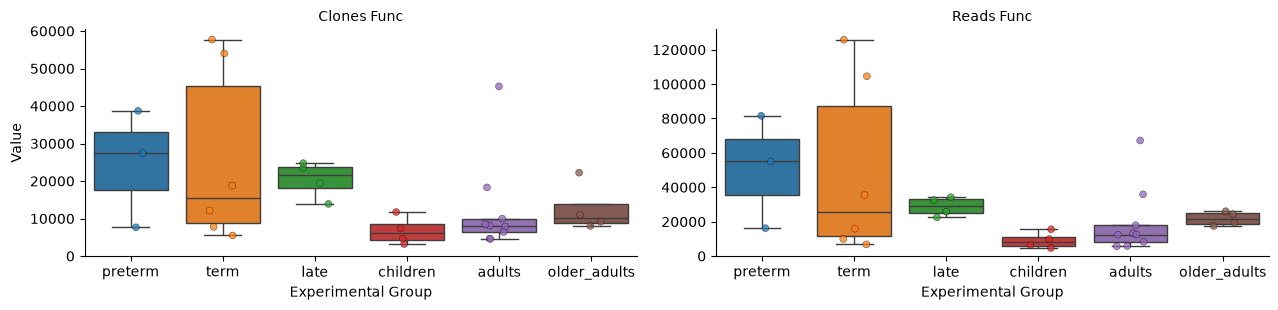

In [10]:
rsplot.clonoset_stats(clonoset_stats_treg, metadata=metadata, group="experimental_group", properties=["clones_func", "reads_func"], aspect=2)

In [11]:
clonoset_stats_treg.sort_values(by="reads_func")

,sample_id,chain,clones,clones_func,clones_func_singletons,clones_func_non_singletons,clones_nonfunc,clones_nonfunc_freq,reads,reads_func,reads_nonfunc,reads_nonfunc_freq,umi,umi_func,umi_nonfunc,umi_nonfunc_freq,reads_per_umi
8,c3_nTreg_TRB_1,TRB,3307,3201,2265,936,106,0.032053,4756,4644,112,0.023549,NaN,NaN,NaN,NaN,NaN
22,a11_nTreg_TRB_1,TRB,4796,4585,3713,872,211,0.043995,5953,5724,229,0.038468,NaN,NaN,NaN,NaN,NaN
9,a10_nTreg_TRB_1,TRB,4862,4636,3702,934,226,0.046483,6115,5872,243,0.039738,NaN,NaN,NaN,NaN,NaN
21,c4_nTreg_TRB_1,TRB,4819,4633,3409,1224,186,0.038597,6622,6416,206,0.031108,NaN,NaN,NaN,NaN,NaN
10,UCB12_nTreg_TRB_1,TRB,5778,5488,4530,958,290,0.050190,7082,6781,301,0.042502,NaN,NaN,NaN,NaN,NaN
26,a7_nTreg_TRB_1,TRB,6711,6402,5040,1362,309,0.046044,8616,8275,341,0.039578,NaN,NaN,NaN,NaN,NaN
0,c5_nTreg_TRB_1,TRB,7674,7415,5724,1691,259,0.033750,10177,9891,286,0.028103,NaN,NaN,NaN,NaN,NaN
5,UCB13_nTreg_TRB_1,TRB,8158,7790,6264,1526,368,0.045109,10381,9977,404,0.038917,NaN,NaN,NaN,NaN,NaN
3,a1_nTreg_TRB_1,TRB,8186,7864,5162,2702,322,0.039335,12793,12413,380,0.029704,NaN,NaN,NaN,NaN,NaN
28,a3_nTreg_TRB_1,TRB,8970,8455,5985,2470,515,0.057414,13118,12509,609,0.046425,NaN,NaN,NaN,NaN,NaN


In [12]:
func_filter = clf.Filter(functionality="f", by_umi=True)
downsample_filter = clf.Filter(functionality="f", downsample=4500, by_umi=True, seed=100)

## Filters

**`Filter` - is a special object, that may be used as a setup for Postanalysis.** You can easily create or change one and put it as an argument to other functions for individual clonoset or multi-clonoset metrics

Here is a basic default filter with all possible options:

In [13]:
clf.Filter(name="default_filter",         # <- name of the filter
           functionality="a",             # <- functional clonotypes = clonotypes without STOP codons or out-of-frames (OOFs) in the CDR3 region, "a" = all clonotypes, "f" = leave only functional, "n" = leave only non-functional
           downsample=None,               # <- randomly downsample to this count value
           top=None,                      # <- take top-N clonotypes
           by_umi=False,                  # <- False = count by read-counts, True = count by UMI counts, if such a column exists
           mix_tails=False,               # <- True = mix all clonotypes with same counts randomly
           count_threshold=None,          # <- set minimal count value for clonotypes, others will be filtered out
           unweight=False,                # <- set count=1 to all clonotypes
           seed=None,                     # <- set seed for random processes, like downsampling and mixing tails for reproducibility
           recount_fractions=True,        # <- should you normalize all fractions to sum to 1 after filtering procedures?
           white_list=[],                 # <- a list of clonotypes, that should be left in the clonoset (the syntax for the list is below)
           black_list=[],                 # <- a list of clonotypes, that should be filtered out
           pool_clonoset_by="",           # <- combine clonotypes into one by CDR3, V or J equlity
           convert=True,                  # <- convert=False preserves all the columns of the original clonoset table. Otherwise the clonoset will be converted into VDJtools-like format for simplicity
           ignore_small_clonosets=False   # <- =True suppreses the warnings when clonoset is smaller than the given downsample or top values.
          )

Here are some examples of useful filters:

### Functional

functionality options: `a` (default) - any. `f` - only functional, `n` - only non-functional

In [14]:
func_filter = clf.Filter(functionality="f", by_umi=True)
func_filter

### Top

top clonotypes by count. Recommended to mix the tails and specify the seed

In [15]:
top_filter = clf.Filter(functionality="f", top=4000, by_umi=True, mix_tails=True, seed=100)
top_filter

### Downsample

Take a random sample by counts (UMI or reads). Seed is recommended to use for reproducibility.

Usually used for Diversity metrics, Convergence and other procedures, which require sample normalization

In [16]:
downsample_filter = clf.Filter(functionality="f", downsample=4500, by_umi=True, seed=100)
downsample_filter

# Analysis

## CDR3 properties

Calculates different properties for CDR3 region. In this case we passed `func_filter` to make calculations only for 'functional' clonotypes

In [17]:
cdr3_properties = stats.calc_cdr3_properties(clonosets_treg, cl_filter=func_filter, cpu=2)
cdr3_properties

Using 2 cores
CalcCDR3aaProperties |##################################################| 30/30 calcultaion(s) processed


,sample_id,chain,mean_cdr3nt_len,mean_insert_size,zero_insert_freq,mean_frequency,cdr3_5_hydropathy,cdr3_full_hydropathy,cdr3_5_charge,cdr3_full_charge,...,cdr3_5_turn,cdr3_full_turn,cdr3_5_alpha,cdr3_full_alpha,cdr3_5_beta,cdr3_full_beta,cdr3_5_core,cdr3_full_core,cdr3_5_disorder,cdr3_full_disorder
0,c5_nTreg_TRB_1,TRB,42.760388,6.987261,0.026893,0.000135,-3.883733,-3.531837,0.099990,-0.291983,...,5.830545,14.798221,4.496963,14.041847,4.820060,13.970178,0.289050,0.767937,2.353250,2.610555
1,UCB6_nTreg_TRB_1,TRB,41.902186,5.946036,0.078276,0.000082,-3.992769,-2.844786,0.203920,-0.075512,...,5.753265,14.394309,4.513517,13.742870,4.852581,13.764531,0.290746,0.753459,2.154605,2.171818
2,o1_nTreg_TRB_1,TRB,43.274845,7.329689,0.023529,0.000124,-3.639415,-3.899485,0.038184,-0.389569,...,5.829768,14.999089,4.498350,14.210788,4.831061,14.137766,0.289456,0.777801,2.334784,2.728876
3,a1_nTreg_TRB_1,TRB,43.030533,7.643599,0.020301,0.000127,-3.449078,-3.180424,0.182712,-0.180214,...,5.786197,14.826571,4.482052,14.129119,4.856840,14.097187,0.289956,0.773829,2.233787,2.510997
4,UCB4_nTreg_TRB_3,TRB,42.743605,5.988319,0.069906,0.000072,-3.335677,-3.234917,0.185335,-0.211983,...,5.763240,14.720730,4.504412,14.041813,4.859102,14.011191,0.290896,0.770504,2.087227,2.297344
5,UCB13_nTreg_TRB_1,TRB,42.682871,6.045605,0.071665,0.000128,-3.449113,-3.192733,0.216598,-0.232435,...,5.738439,14.629522,4.525081,14.101001,4.856143,13.973263,0.290537,0.768480,2.101534,2.367946
6,a16_nTreg_TRB_1,TRB,43.288565,7.518935,0.021635,0.000022,-3.637947,-3.260799,0.168276,-0.186221,...,5.802027,14.949630,4.489763,14.209245,4.839746,14.159931,0.289714,0.778259,2.293059,2.592411
7,UCB10_nTreg_TRB_1,TRB,42.645039,5.702068,0.099645,0.000017,-3.669230,-3.316600,0.213042,-0.155981,...,5.758222,14.688985,4.508051,14.001931,4.855939,13.978145,0.290938,0.767903,2.117348,2.303855
8,c3_nTreg_TRB_1,TRB,42.819767,7.014427,0.027347,0.000312,-3.794165,-3.130728,0.126184,-0.133075,...,5.827933,14.818094,4.489328,14.036882,4.819184,13.987442,0.289697,0.769859,2.292420,2.550818
9,a10_nTreg_TRB_1,TRB,43.570504,7.673195,0.021628,0.000216,-3.630858,-4.140719,0.174217,-0.305007,...,5.783966,15.021591,4.511630,14.353374,4.843295,14.247868,0.290264,0.786755,2.282187,2.701805


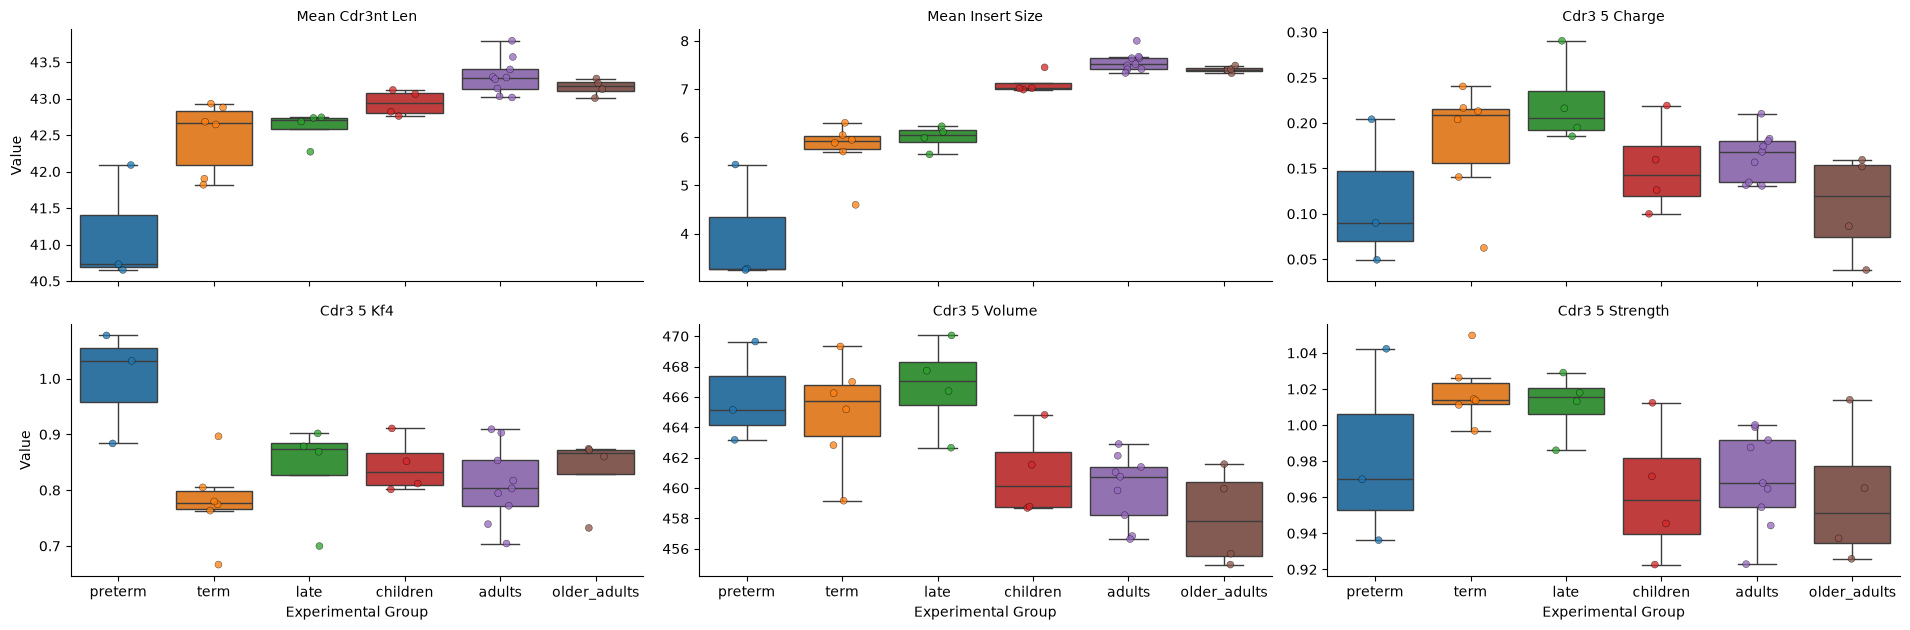

In [18]:
rsplot.cdr3aa_stats(cdr3_properties,
                     metadata=metadata,
                     properties=None,
                     group="experimental_group",
                     split=None,
                     palette=None,
                     height=3.2,
                     aspect=2,
                    )

In [19]:
cdr3_properties.to_csv(os.path.join(WORKING_DIR, "cdr3_properties.csv"), index=False)

## CDR3len distributions

In [20]:
preterm_late_tregs = clonosets_treg.query("experimental_group in ['preterm', 'late']")
preterm_late_tregs

,sample_id,chain,filename,experimental_group,donor_id,subset,source
4,UCB4_nTreg_TRB_3,TRB,/home/mmyshkin/projects/ucb/fastq_upload/figsh...,late,UCB4,nTreg,UCB
12,UCB9_nTreg_TRB_1,TRB,/home/mmyshkin/projects/ucb/fastq_upload/figsh...,late,UCB9,nTreg,UCB
14,UCB7_nTreg_TRB_1,TRB,/home/mmyshkin/projects/ucb/fastq_upload/figsh...,late,UCB7,nTreg,UCB
17,UCB11_nTreg_TRB_1,TRB,/home/mmyshkin/projects/ucb/fastq_upload/figsh...,preterm,UCB11,nTreg,UCB
19,UCB1_nTreg_TRB_2,TRB,/home/mmyshkin/projects/ucb/fastq_upload/figsh...,preterm,UCB1,nTreg,UCB
20,UCB8_nTreg_TRB_1,TRB,/home/mmyshkin/projects/ucb/fastq_upload/figsh...,late,UCB8,nTreg,UCB
25,UCB5_nTreg_TRB_1,TRB,/home/mmyshkin/projects/ucb/fastq_upload/figsh...,preterm,UCB5,nTreg,UCB


In [21]:
cdr3_len_distribs = stats.cdr3_length_distributions(
                                                        preterm_late_tregs,
                                                        cl_filter=func_filter,
                                                        cpu=None,
                                                        count_by_freq=True,
                                                        seq_type="aa",
                                                        table="long",
                                                        zero_fill=True,
                                                        verbose=True,
                                                        drop_small_samples=False,
                                                    )
cdr3_len_distribs

Using all available worker processes by default. Set cpu=1 or another integer to change this.
CalcCDR3LengthDistribution |##################################################| 7/7 calcultaion(s) processed


,sample_id,chain,cdr3_length,freq
0,UCB11_nTreg_TRB_1,TRB,5,0.000000
1,UCB11_nTreg_TRB_1,TRB,6,0.000000
2,UCB11_nTreg_TRB_1,TRB,7,0.000740
3,UCB11_nTreg_TRB_1,TRB,8,0.000740
4,UCB11_nTreg_TRB_1,TRB,9,0.001356
...,...,...,...,...
135,UCB9_nTreg_TRB_1,TRB,20,0.001519
136,UCB9_nTreg_TRB_1,TRB,21,0.000438
137,UCB9_nTreg_TRB_1,TRB,22,0.000000
138,UCB9_nTreg_TRB_1,TRB,23,0.000058


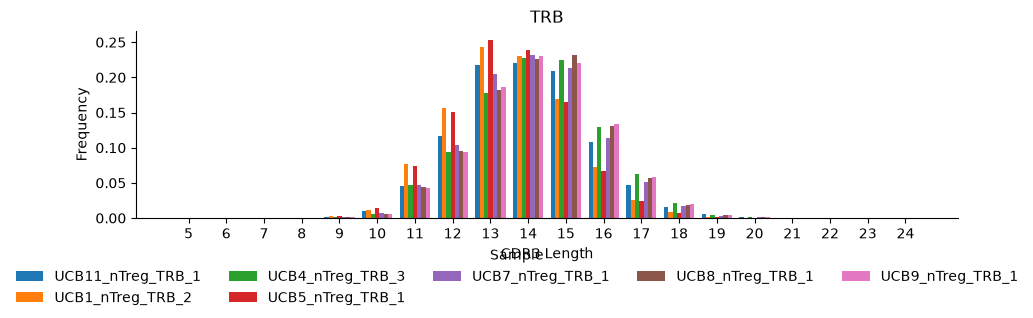

In [22]:
rsplot.cdr3_length_distributions(cdr3_len_distribs)

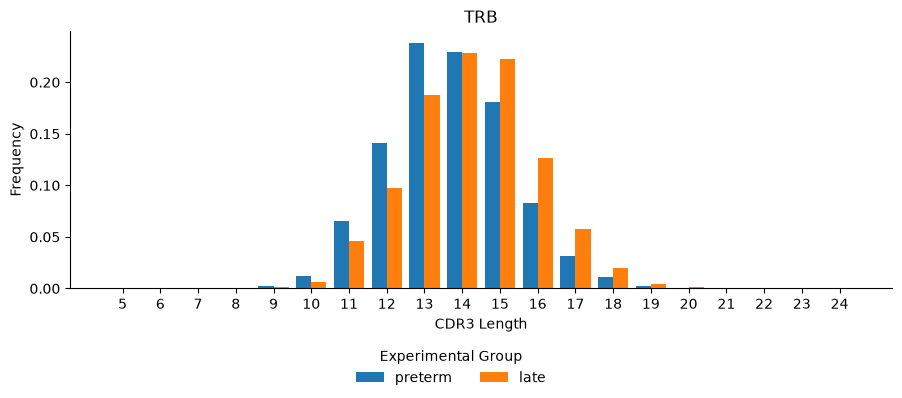

In [23]:
rsplot.cdr3_length_distributions(cdr3_len_distribs, metadata=metadata, group="experimental_group", height=4)

## Segment usage

### V-usage

In [24]:
v_usage = stats.calc_segment_usage(clonosets_treg, segment="v", cl_filter=func_filter, table="long")
v_usage

Using all available worker processes by default. Set cpu=1 or another integer to change this.
CalcSegmentUsage |##################################################| 30/30 calcultaion(s) processed


,sample_id,chain,v,usage
0,c5_nTreg_TRB_1,TRB,TRBV1,0.000202
1,UCB6_nTreg_TRB_1,TRB,TRBV1,0.000377
2,o1_nTreg_TRB_1,TRB,TRBV1,0.000057
3,a1_nTreg_TRB_1,TRB,TRBV1,0.000242
4,UCB4_nTreg_TRB_3,TRB,TRBV1,0.000355
...,...,...,...,...
1825,UCB5_nTreg_TRB_1,TRB,TRBV17,0.000000
1826,a7_nTreg_TRB_1,TRB,TRBV17,0.000000
1827,a5_nTreg_TRB_1,TRB,TRBV17,0.000000
1828,a3_nTreg_TRB_1,TRB,TRBV17,0.000000


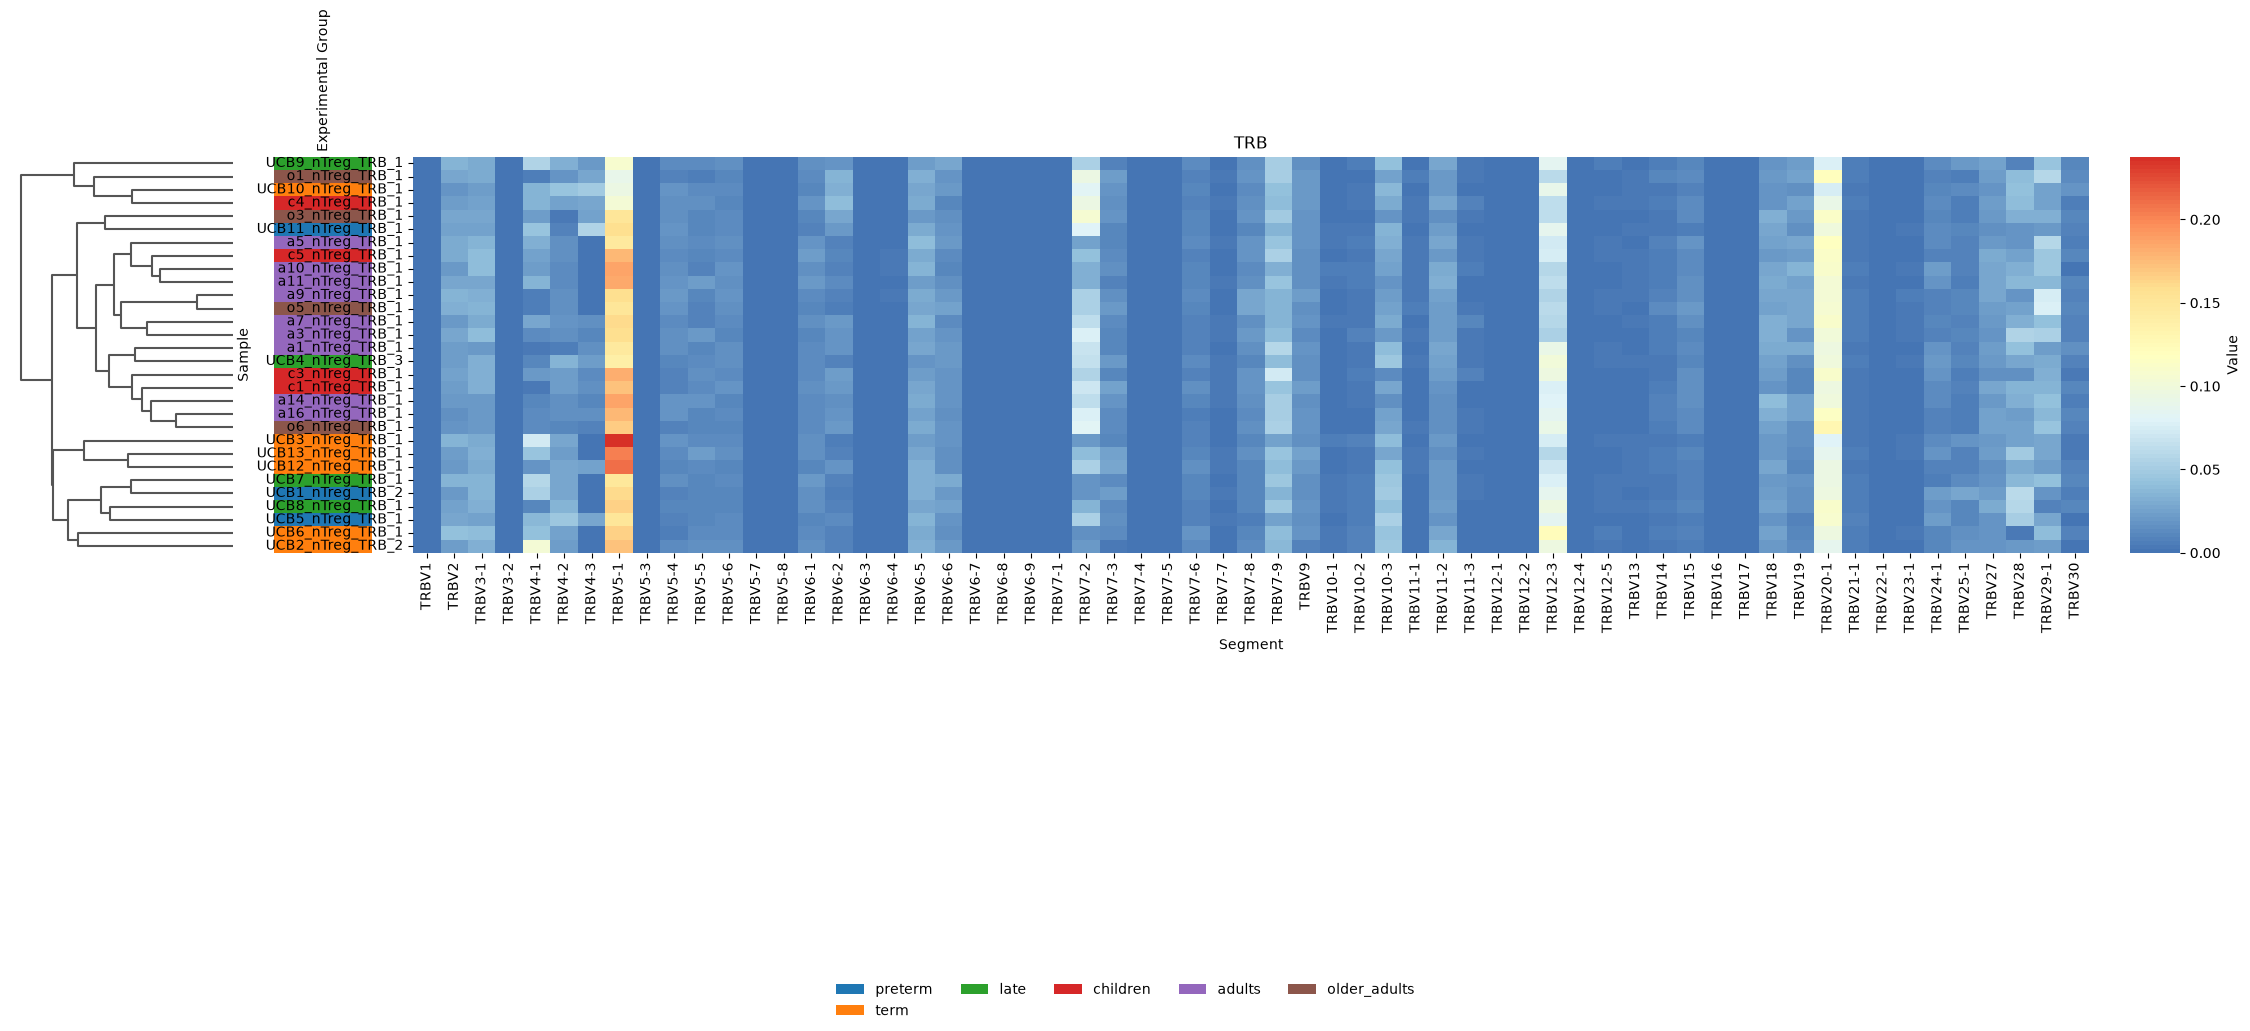

In [25]:
rsplot.segment_usage(v_usage, metadata=metadata, group="experimental_group", plot_type="heatmap", height=7)

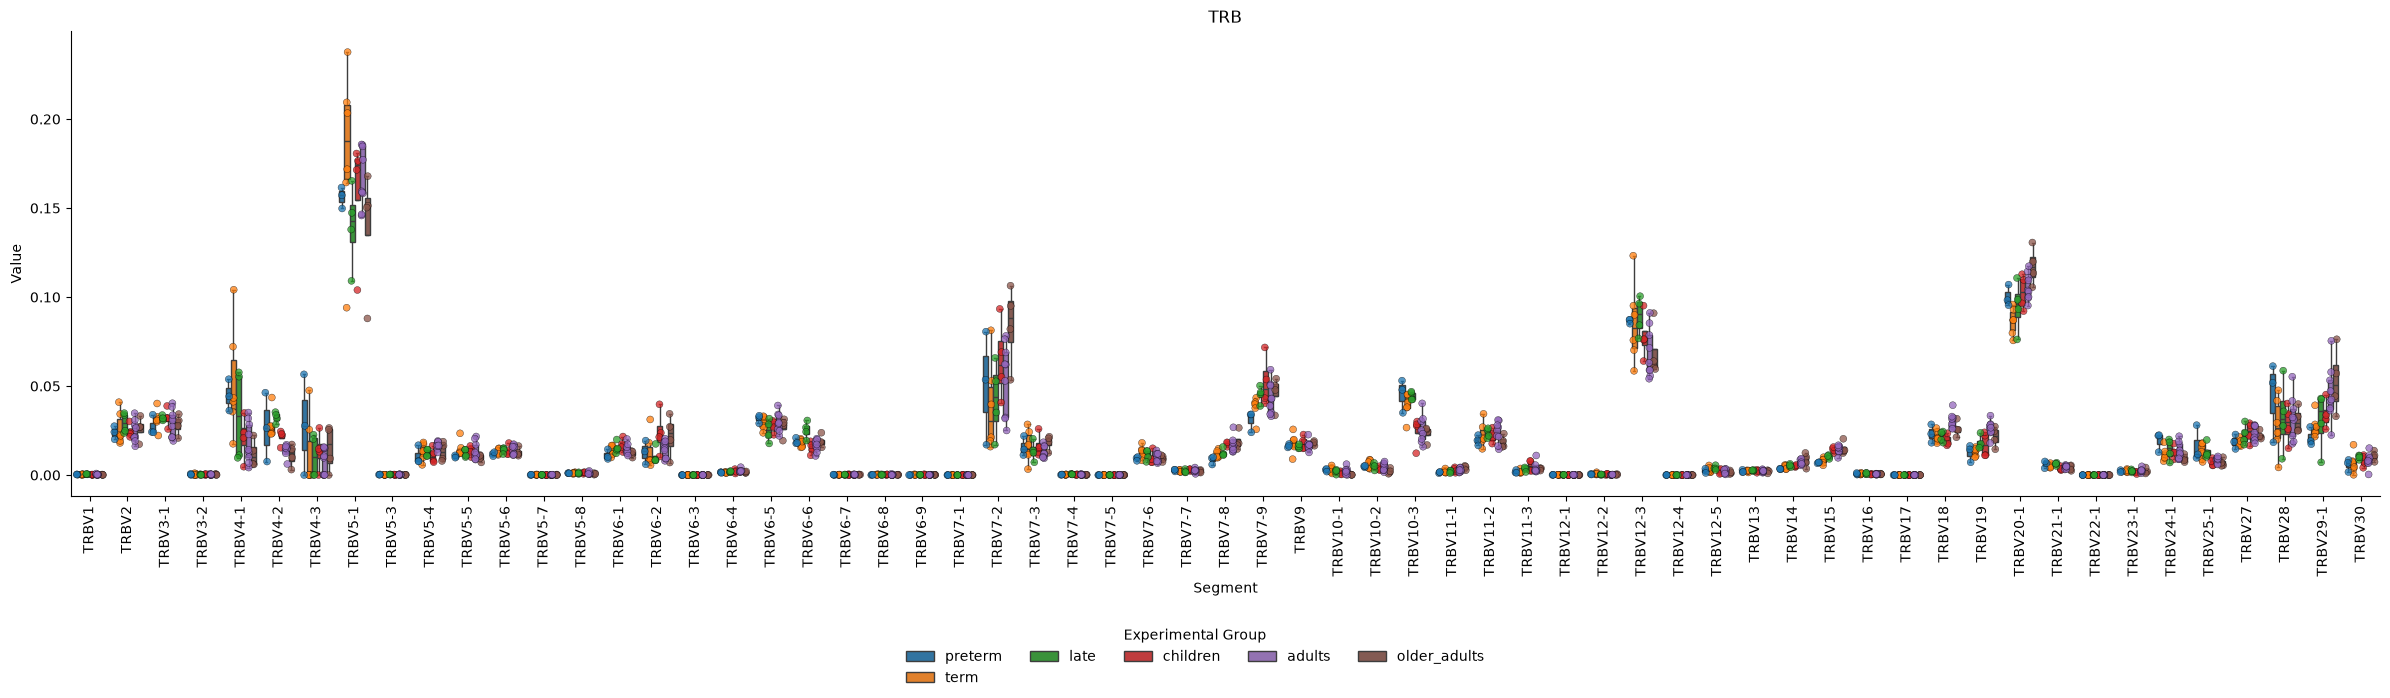

In [26]:
rsplot.segment_usage(v_usage, metadata=metadata, group="experimental_group", plot_type="boxplot", height=7, )

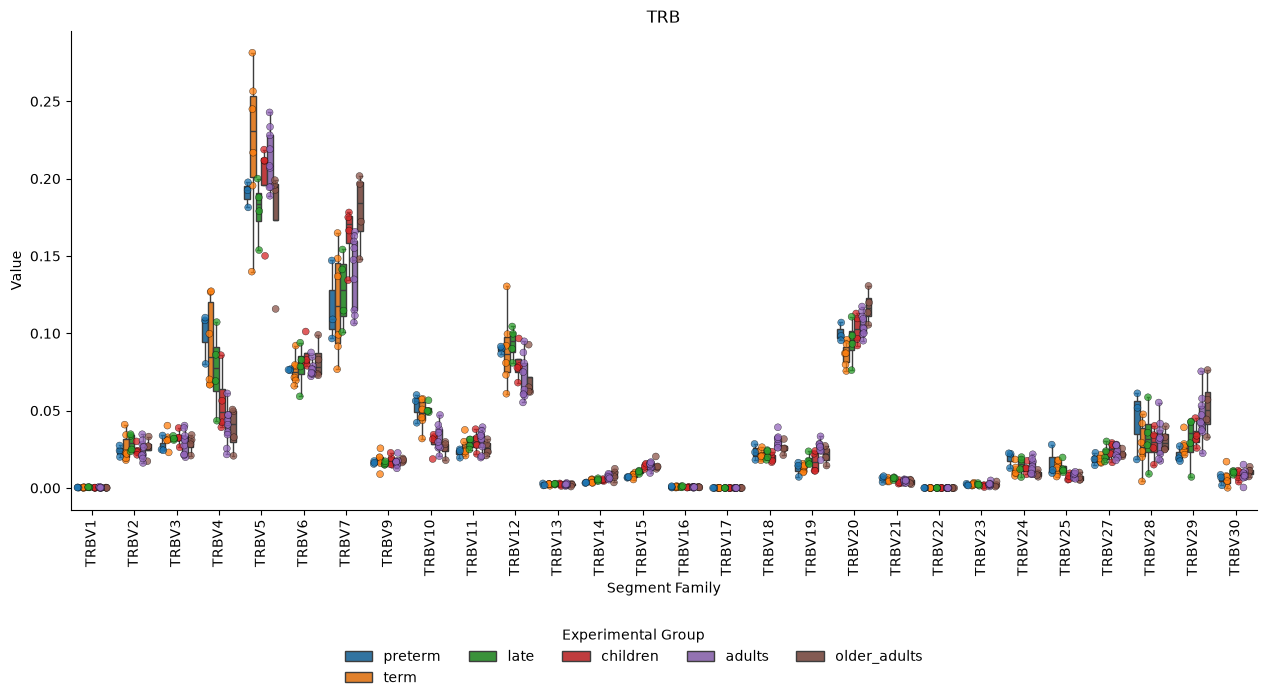

In [27]:
rsplot.segment_usage(v_usage, metadata=metadata, group="experimental_group", plot_type="boxplot", height=7, combine_families=True)

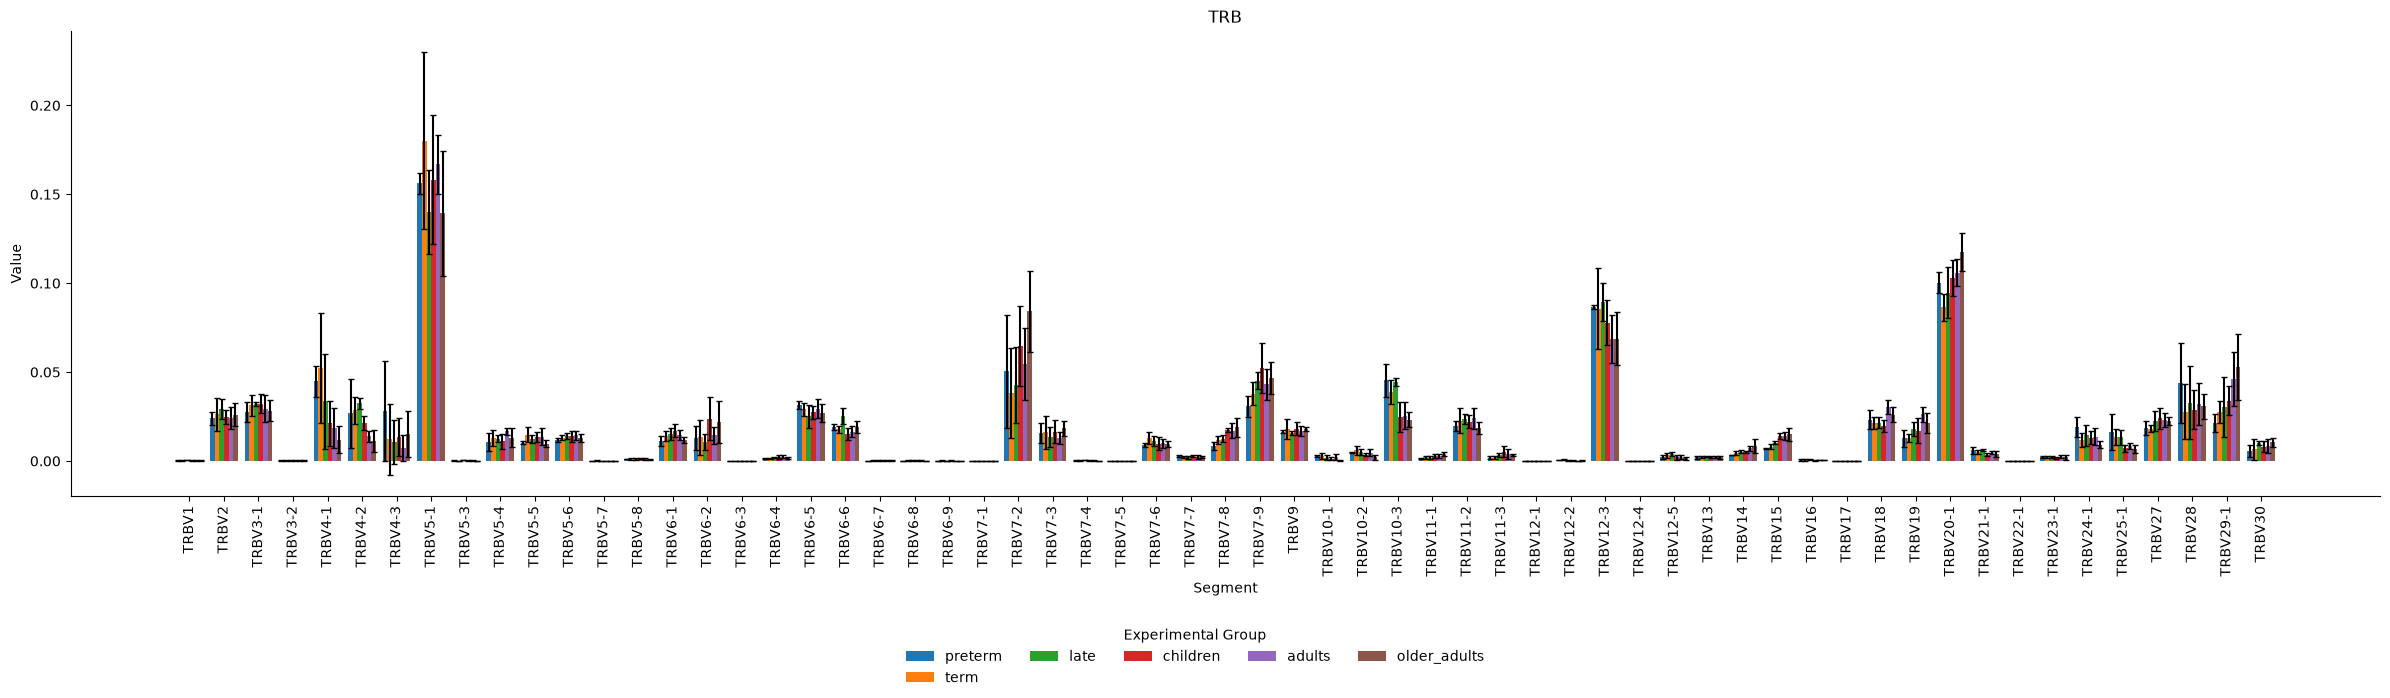

In [28]:
rsplot.segment_usage(v_usage, metadata=metadata, group="experimental_group", plot_type="barplot", height=7)

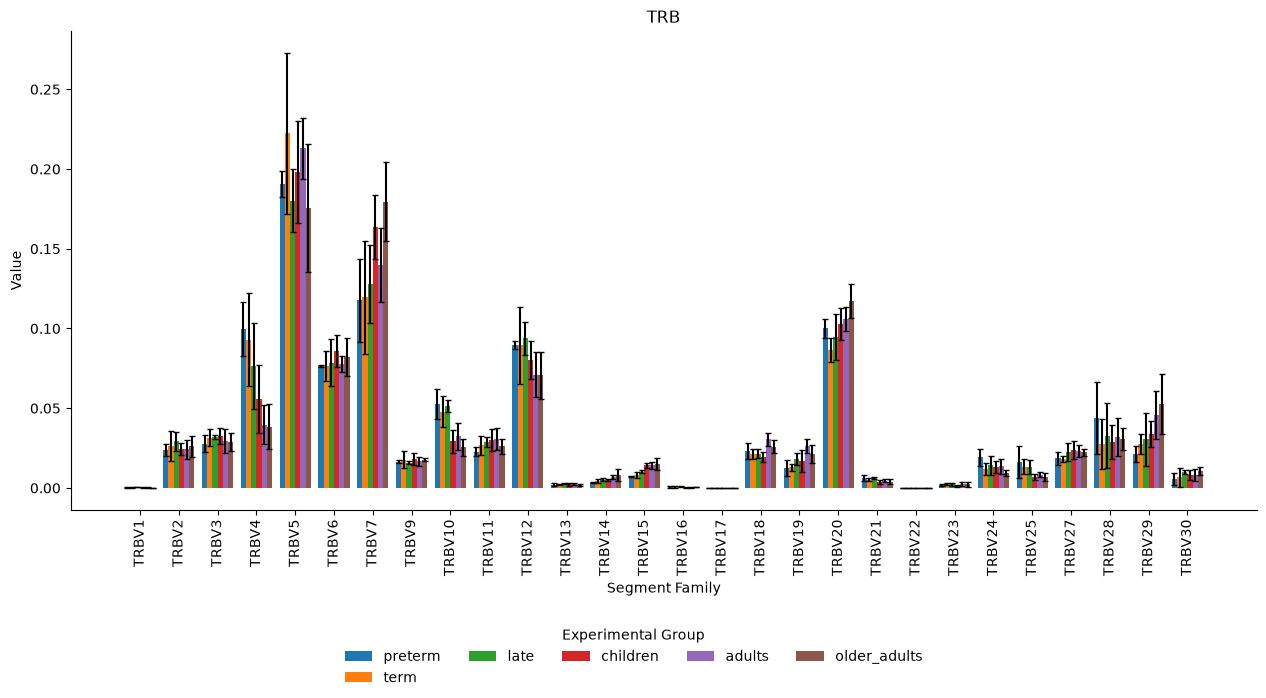

In [29]:
rsplot.segment_usage(v_usage, metadata=metadata, group="experimental_group", plot_type="barplot", height=7, combine_families=True)

### J-usage

In [30]:
j_usage = stats.calc_segment_usage(clonosets_treg, segment="j", cl_filter=func_filter)
j_usage

Using all available worker processes by default. Set cpu=1 or another integer to change this.
CalcSegmentUsage |##################################################| 30/30 calcultaion(s) processed


,sample_id,chain,j,usage
0,c5_nTreg_TRB_1,TRB,TRBJ1-1,0.110302
1,UCB6_nTreg_TRB_1,TRB,TRBJ1-1,0.125581
2,o1_nTreg_TRB_1,TRB,TRBJ1-1,0.088676
3,a1_nTreg_TRB_1,TRB,TRBJ1-1,0.103440
4,UCB4_nTreg_TRB_3,TRB,TRBJ1-1,0.070528
...,...,...,...,...
385,UCB5_nTreg_TRB_1,TRB,TRBJ2-7,0.168243
386,a7_nTreg_TRB_1,TRB,TRBJ2-7,0.203021
387,a5_nTreg_TRB_1,TRB,TRBJ2-7,0.125299
388,a3_nTreg_TRB_1,TRB,TRBJ2-7,0.140379


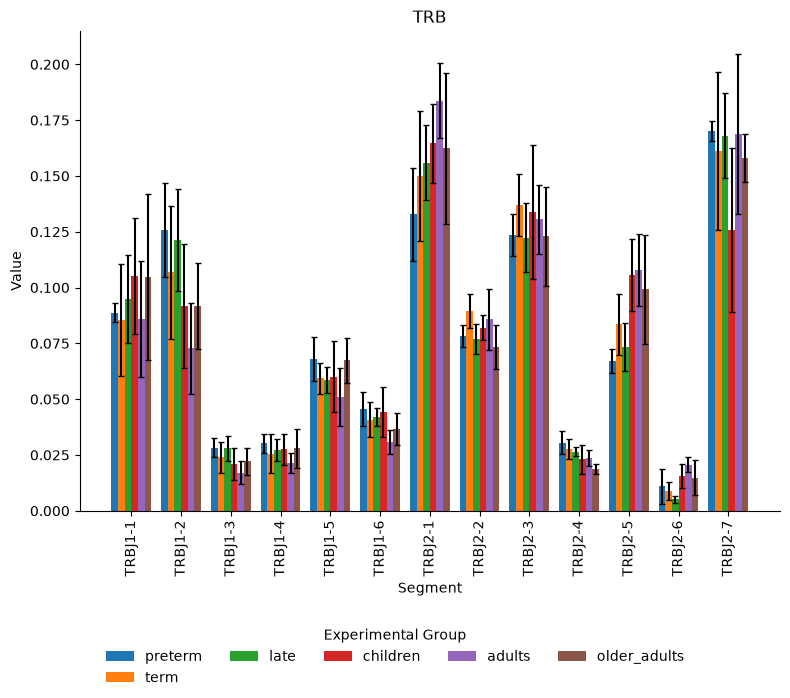

In [31]:
rsplot.segment_usage(j_usage, metadata=metadata, group="experimental_group", plot_type="barplot", height=7)

## Convergence

In [32]:
convergence = stats.calc_convergence(clonosets_treg,
                                     cl_filter=downsample_filter,
                                     seed=42,
                                     cpu=2,
                                     verbose=True
                                    )
convergence

CalcConvergence settings: seed=42, downsample=4500, top=None, iterations=3
Calcultating stats for original clonosets
_________________________________________
Using 2 cores
CalcClonosetStats |##################################################| 30/30 calcultaion(s) processed
WARNING! Following samples have NaN downsample counts ('umi_func'): c5_nTreg_TRB_1, UCB6_nTreg_TRB_1, o1_nTreg_TRB_1, a1_nTreg_TRB_1, UCB4_nTreg_TRB_3, UCB13_nTreg_TRB_1, a16_nTreg_TRB_1, UCB10_nTreg_TRB_1, c3_nTreg_TRB_1, a10_nTreg_TRB_1, UCB12_nTreg_TRB_1, a14_nTreg_TRB_1, UCB9_nTreg_TRB_1, UCB2_nTreg_TRB_2, UCB7_nTreg_TRB_1, o3_nTreg_TRB_1, a9_nTreg_TRB_1, UCB11_nTreg_TRB_1, o5_nTreg_TRB_1, UCB1_nTreg_TRB_2, UCB8_nTreg_TRB_1, c4_nTreg_TRB_1, a11_nTreg_TRB_1, c1_nTreg_TRB_1, UCB3_nTreg_TRB_1, UCB5_nTreg_TRB_1, a7_nTreg_TRB_1, a5_nTreg_TRB_1, a3_nTreg_TRB_1, o6_nTreg_TRB_1
These samples will be counted by reads instead
Using 2 cores
CalcConvergence |##################################################| 30/30 calculta

,sample_id,chain,convergence,convergence_v,convergence_vj
0,c5_nTreg_TRB_1,TRB,1.002730,1.000272,1.000272
1,UCB6_nTreg_TRB_1,TRB,1.006597,1.001214,1.001214
2,o1_nTreg_TRB_1,TRB,1.002753,1.002446,1.002446
3,a1_nTreg_TRB_1,TRB,1.001935,1.000552,1.000552
4,UCB4_nTreg_TRB_3,TRB,1.008629,1.000504,1.000504
5,UCB13_nTreg_TRB_1,TRB,1.006472,1.000804,1.000804
6,a16_nTreg_TRB_1,TRB,1.002079,1.000461,1.000461
7,UCB10_nTreg_TRB_1,TRB,1.011103,1.001635,1.001635
8,c3_nTreg_TRB_1,TRB,1.001403,1.000350,1.000350
9,a10_nTreg_TRB_1,TRB,1.001661,1.000829,1.000829


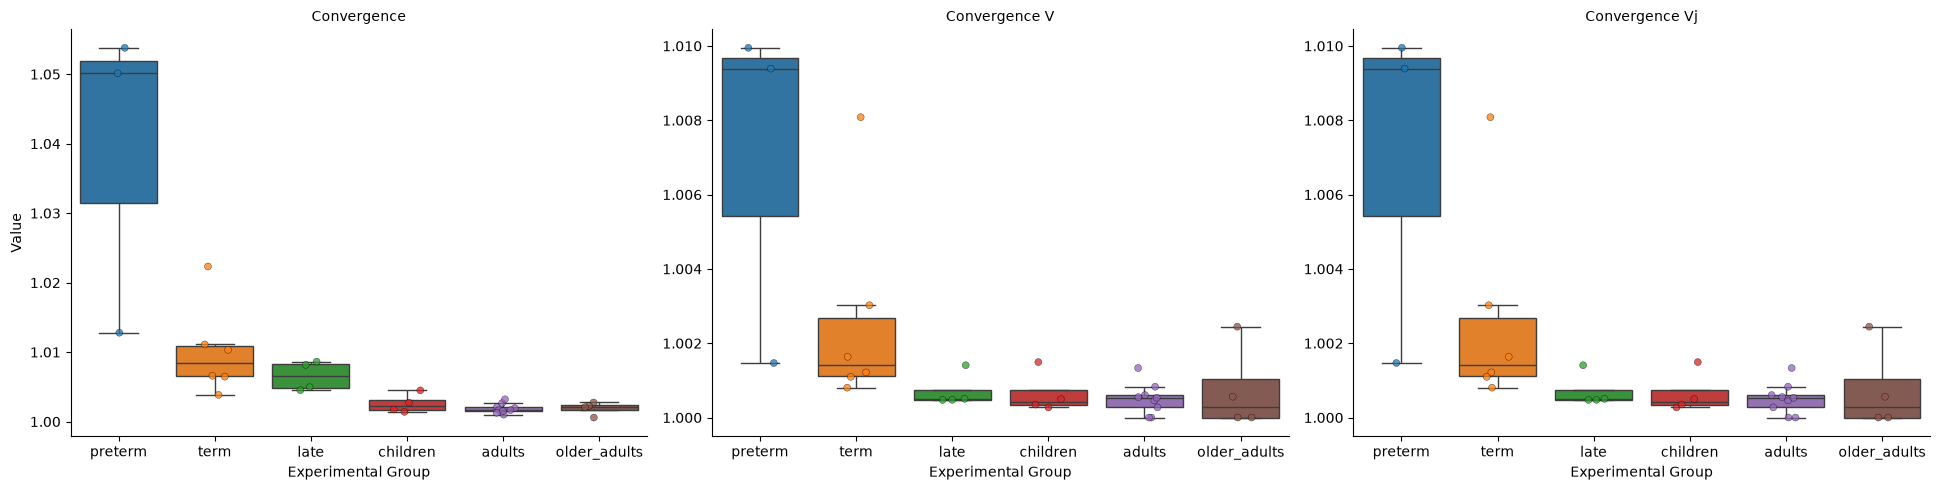

In [34]:
rsplot.convergence(convergence,
                     metadata=metadata,
                     group="experimental_group",
                     height=5,
                     aspect=1.3
                  )

## Diversity stats

In [35]:
diversity_stats = stats.calc_diversity_stats(clonosets_treg,
                                             cl_filter=downsample_filter, seed=123, cpu=2,
                                             iterations=3,
                                             drop_small_samples=False, 
                                             verbose=True
                                            )
diversity_stats

CalcDiversityStats settings: seed=123, downsample=4500, top=None, iterations=3
Calcultating stats for original clonosets
_________________________________________
Using 2 cores
CalcClonosetStats |##################################################| 30/30 calcultaion(s) processed
WARNING! Following samples have NaN downsample counts ('umi_func'): c5_nTreg_TRB_1, UCB6_nTreg_TRB_1, o1_nTreg_TRB_1, a1_nTreg_TRB_1, UCB4_nTreg_TRB_3, UCB13_nTreg_TRB_1, a16_nTreg_TRB_1, UCB10_nTreg_TRB_1, c3_nTreg_TRB_1, a10_nTreg_TRB_1, UCB12_nTreg_TRB_1, a14_nTreg_TRB_1, UCB9_nTreg_TRB_1, UCB2_nTreg_TRB_2, UCB7_nTreg_TRB_1, o3_nTreg_TRB_1, a9_nTreg_TRB_1, UCB11_nTreg_TRB_1, o5_nTreg_TRB_1, UCB1_nTreg_TRB_2, UCB8_nTreg_TRB_1, c4_nTreg_TRB_1, a11_nTreg_TRB_1, c1_nTreg_TRB_1, UCB3_nTreg_TRB_1, UCB5_nTreg_TRB_1, a7_nTreg_TRB_1, a5_nTreg_TRB_1, a3_nTreg_TRB_1, o6_nTreg_TRB_1
These samples will be counted by reads instead
Using 2 cores
CalcDiversityStats |##################################################| 30/30 c

,sample_id,chain,diversity,norm_shannon_wiener,clonality,shannon_wiener,chao1,richness,ace,goods_coverage,d50,simpson,inverse_simpson,gini_simpson,berger_parker,gini_coefficient
0,c5_nTreg_TRB_1,TRB,3856.0,0.993202,0.006798,8.201251,15839.358862,3856.0,15641.354834,0.264444,0.416494,0.000297,3371.628372,0.999703,0.001111,0.125471
1,UCB6_nTreg_TRB_1,TRB,4153.0,0.996265,0.003735,8.300465,30694.586331,4153.0,30657.110836,0.146222,0.458223,0.000260,3839.590444,0.999740,0.001111,0.071877
2,o1_nTreg_TRB_1,TRB,3403.0,0.987869,0.012131,8.033758,9009.613712,3403.0,8944.194765,0.424444,0.338819,0.000370,2705.772314,0.999630,0.002444,0.197425
3,a1_nTreg_TRB_1,TRB,3719.0,0.991527,0.008473,8.151553,13372.911111,3719.0,13131.608012,0.312889,0.394999,0.000317,3155.188532,0.999683,0.001111,0.149000
4,UCB4_nTreg_TRB_3,TRB,4024.0,0.995047,0.004953,8.258921,21299.200000,4024.0,21117.501667,0.200000,0.440855,0.000275,3640.776699,0.999725,0.000889,0.095717
5,UCB13_nTreg_TRB_1,TRB,3950.0,0.994009,0.005991,8.231859,19301.653165,3950.0,19229.438574,0.226000,0.430380,0.000286,3497.409326,0.999714,0.001111,0.109655
6,a16_nTreg_TRB_1,TRB,4350.0,0.998461,0.001539,8.365041,67485.071429,4350.0,67385.123567,0.065556,0.482759,0.000238,4209.979210,0.999762,0.000667,0.032258
7,UCB10_nTreg_TRB_1,TRB,4306.0,0.997957,0.002043,8.350673,54315.564706,4306.0,53940.153405,0.083556,0.477473,0.000243,4122.557003,0.999757,0.000667,0.041394
8,c3_nTreg_TRB_1,TRB,3134.0,0.983998,0.016002,7.921248,7480.065858,3134.0,7422.100487,0.502222,0.283663,0.000425,2353.556485,0.999575,0.001556,0.238839
9,a10_nTreg_TRB_1,TRB,3740.0,0.991707,0.008293,8.158614,13647.454361,3740.0,13594.028548,0.305333,0.398396,0.000315,3178.963893,0.999685,0.001111,0.145592


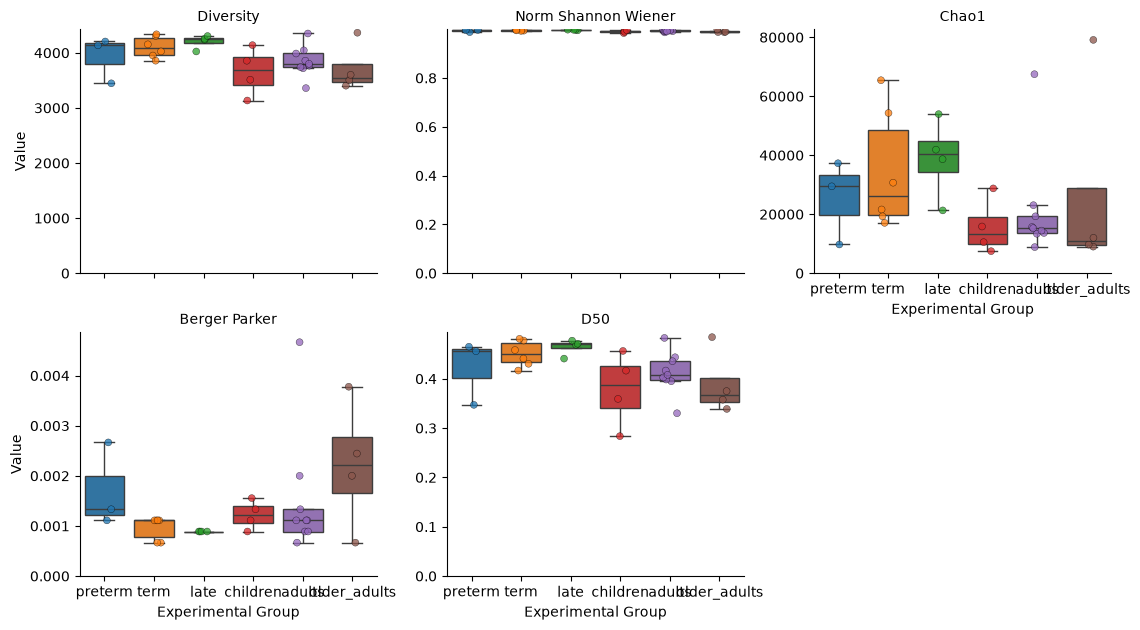

In [36]:
rsplot.diversity_stats(diversity_stats,
                     metadata=metadata,
                     group="experimental_group"
                    )

## Rarefaction

In [37]:
rarefaction_points_ucb = stats.calc_rarefaction_curve(clonosets_treg, cl_filter=clf.Filter(functionality="f", by_umi=True))
rarefaction_points_ucb

Using all available worker processes by default. Set cpu=1 or another integer to change this.
CalcRarefactionPoints |##################################################| 30/30 calcultaion(s) processed


,sample_id,chain,rarefaction_depth,diversity
0,UCB10_nTreg_TRB_1,TRB,32,32.000000
1,UCB10_nTreg_TRB_1,TRB,100,99.666667
2,UCB10_nTreg_TRB_1,TRB,316,315.000000
3,UCB10_nTreg_TRB_1,TRB,1000,988.000000
4,UCB10_nTreg_TRB_1,TRB,3162,3070.000000
...,...,...,...,...
208,o6_nTreg_TRB_1,TRB,316,316.000000
209,o6_nTreg_TRB_1,TRB,1000,994.000000
210,o6_nTreg_TRB_1,TRB,3162,3092.000000
211,o6_nTreg_TRB_1,TRB,10000,9359.000000


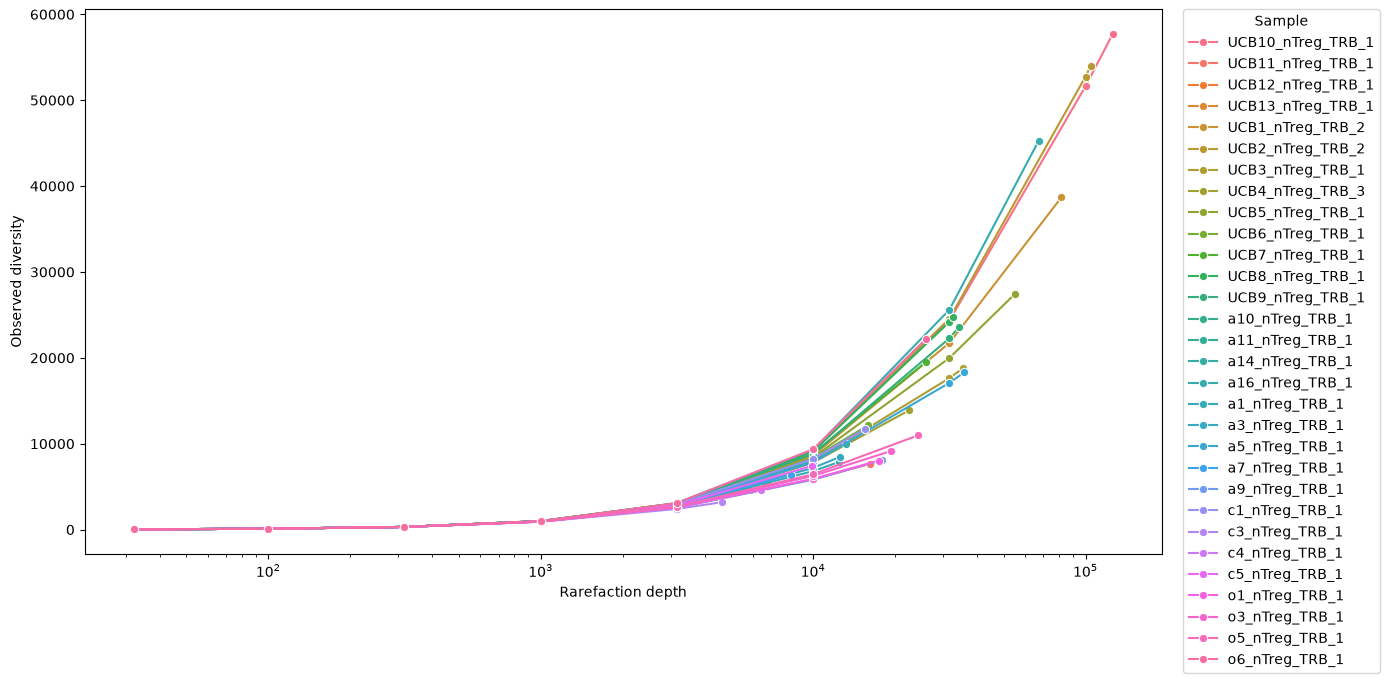

In [38]:
rsplot.rarefaction_curve(rarefaction_points_ucb, log_x=True, aspect=2, height=7)

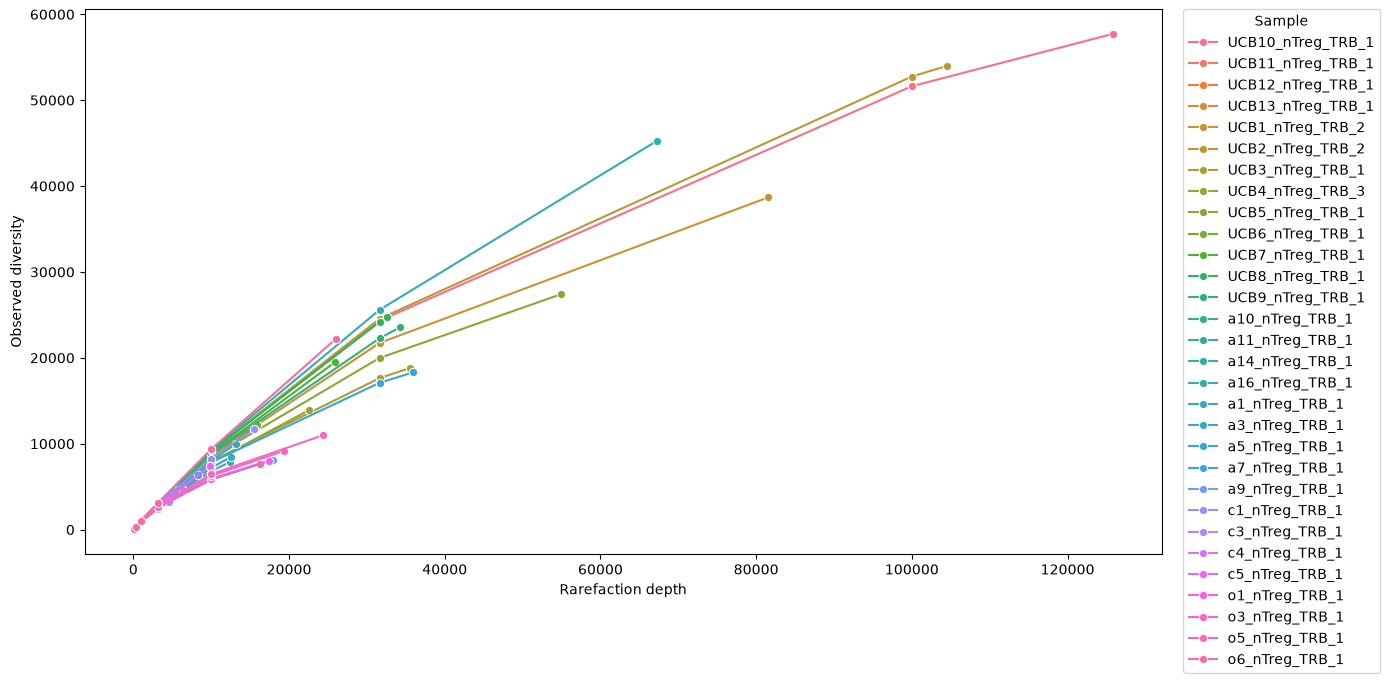

In [39]:
rsplot.rarefaction_curve(rarefaction_points_ucb, log_x=False, aspect=2, height=7)

## Beta-diversity

### Main function for beta-diversity 

**`beta.metrics`** function calculates a diverse set of Beta-diversity metrics which include (for more detailed explanation refer to **THIS LINK**):

- Number of intersecting clonotypes ('number_of_intersecting_clonotypes')
- Relative diversity ('relative_diversity')
- Pearson correlation ('pearson')
- F1 ('f1') metric - geometric mean of total frequencies of intersecting clonotypes in both samples
- F2 ('f2') metric - sum of geometric means of frequencies of each clonotype in the samples
- ', 'f1', 'f2', 'jaccard', 'jaccard_distance', 'dice', 'dice_distance', 'szymkiewicz_simpson', 'bray_curtis', 'l1', 'total_variation', 'l2', 'morisita_horn', 'jensen_shannon', 'kl_divergence', 'hellinger', 'full_table'

Required input is only the sample_df - DataFrame with the set of repertoires

By default it outputs a dictionary, containing metrics as keys and DataFrames with each metric (or mainly matrices) as values.

In [40]:
beta_diversity = beta.metrics(clonosets_treg,                     # <- clonosets_df - DataFrame with clonosets - sample_id, filename
                              cl_filter=downsample_filter,        # <- you can use a filter to preprocess all the clonosets before intersecting
                              overlap_type="aaV",                     # <- overlap type - is a defenition of similar clonotypes. aaV = similar clonotypes have same CDR3 amino acid sequence and same V gene, and we are not concidering V gene
                              clonosets_df2=None,                     # <- you can pass a second set of clonosets for intersection, otherwise it will intersect all possible pairs with each other
                              cl_filter2=None,                        # <- you can pass a different filter for second set of clonosets, otherwise it will be preprocessed with cl_filter
                              metrics=None,                           # <- you can limit the metrics to a list or a single metric for simplicity of the output
                              cpu=None                                # <- cpus for parallel calculation (=None means - take all avaiable)
                              )

Intersecting clones in clonosets
--------------------------------------------------
Overlap type: aaV
Reading clonosets |##################################################| 30/30 sample(s) processed
Using all available worker processes by default. Set cpu=1 or another integer to change this.
Intersecting clonosets |##################################################| 435/435 pairs processed


In [41]:
beta_diversity.keys()

dict_keys(['number_of_intersecting_clonotypes', 'relative_diversity', 'pearson', 'f1', 'f2', 'jaccard', 'jaccard_distance', 'dice', 'dice_distance', 'szymkiewicz_simpson', 'bray_curtis', 'l1', 'total_variation', 'l2', 'morisita_horn', 'jensen_shannon', 'kl_divergence', 'hellinger', 'full_table'])

In [42]:
beta_diversity["f2"]

sample2,UCB10_nTreg_TRB_1,UCB11_nTreg_TRB_1,UCB12_nTreg_TRB_1,UCB13_nTreg_TRB_1,UCB1_nTreg_TRB_2,UCB2_nTreg_TRB_2,UCB3_nTreg_TRB_1,UCB4_nTreg_TRB_3,UCB5_nTreg_TRB_1,UCB6_nTreg_TRB_1,...,a7_nTreg_TRB_1,a9_nTreg_TRB_1,c1_nTreg_TRB_1,c3_nTreg_TRB_1,c4_nTreg_TRB_1,c5_nTreg_TRB_1,o1_nTreg_TRB_1,o3_nTreg_TRB_1,o5_nTreg_TRB_1,o6_nTreg_TRB_1
sample1,,,,,,,,,,,,,,,,,,,,,
UCB10_nTreg_TRB_1,1.000000,0.005834,0.003642,0.002054,0.014294,0.005794,0.007542,0.003295,0.014031,0.005290,...,0.001295,0.000314,0.002000,0.000759,0.001052,0.001924,0.001073,0.001387,0.001203,0.000000
UCB11_nTreg_TRB_1,0.005834,1.000000,0.002753,0.002065,0.012775,0.004995,0.009403,0.004381,0.014595,0.003989,...,0.001425,0.002165,0.001333,0.000607,0.001609,0.002276,0.001144,0.002460,0.001740,0.001680
UCB12_nTreg_TRB_1,0.003642,0.002753,1.000000,0.002417,0.005614,0.002477,0.008466,0.003165,0.008970,0.000444,...,0.000759,0.000759,0.000759,0.001165,0.001203,0.000859,0.000314,0.000536,0.000222,0.001436
UCB13_nTreg_TRB_1,0.002054,0.002065,0.002417,1.000000,0.010465,0.003609,0.008484,0.005005,0.008867,0.003663,...,0.000759,0.000851,0.000851,0.000314,0.002116,0.001832,0.000629,0.001740,0.001832,0.001333
UCB1_nTreg_TRB_2,0.014294,0.012775,0.005614,0.010465,1.000000,0.015706,0.029585,0.009718,0.043037,0.012603,...,0.001425,0.002125,0.003013,0.003727,0.002054,0.002498,0.000981,0.002108,0.003165,0.002753
UCB2_nTreg_TRB_2,0.005794,0.004995,0.002477,0.003609,0.015706,1.000000,0.012921,0.003740,0.016080,0.007929,...,0.000759,0.001387,0.002439,0.000889,0.001144,0.000629,0.000981,0.001295,0.001517,0.001333
UCB3_nTreg_TRB_1,0.007542,0.009403,0.008466,0.008484,0.029585,0.012921,1.000000,0.011183,0.030074,0.011580,...,0.002054,0.002184,0.003431,0.001303,0.001436,0.003387,0.000667,0.004593,0.003926,0.001295
UCB4_nTreg_TRB_3,0.003295,0.004381,0.003165,0.005005,0.009718,0.003740,0.011183,1.000000,0.012413,0.003617,...,0.001203,0.002184,0.002000,0.001084,0.000444,0.000444,0.001144,0.001295,0.001659,0.000981
UCB5_nTreg_TRB_1,0.014031,0.014595,0.008970,0.008867,0.043037,0.016080,0.030074,0.012413,1.000000,0.016066,...,0.002889,0.001073,0.002943,0.002721,0.001843,0.003924,0.000981,0.002813,0.002813,0.002276


In [43]:
beta_diversity["full_table"].query("pair == 'UCB10_nTreg_TRB_1_vs_UCB11_nTreg_TRB_1'")

,cdr3aa,v,sample1_count,sample2_count,sample1_freq,sample2_freq,sample1,sample2,pair
0,CATSDRGTEAFF,TRBV24-1,1,0,0.000222,0.000000,UCB10_nTreg_TRB_1,UCB11_nTreg_TRB_1,UCB10_nTreg_TRB_1_vs_UCB11_nTreg_TRB_1
1,CASSLGLAAYNEQFF,TRBV5-1,1,0,0.000222,0.000000,UCB10_nTreg_TRB_1,UCB11_nTreg_TRB_1,UCB10_nTreg_TRB_1_vs_UCB11_nTreg_TRB_1
2,CASSFGSTDTQYF,TRBV7-9,0,1,0.000000,0.000222,UCB10_nTreg_TRB_1,UCB11_nTreg_TRB_1,UCB10_nTreg_TRB_1_vs_UCB11_nTreg_TRB_1
3,CASSQPRMHTQYF,TRBV4-1,1,0,0.000222,0.000000,UCB10_nTreg_TRB_1,UCB11_nTreg_TRB_1,UCB10_nTreg_TRB_1_vs_UCB11_nTreg_TRB_1
4,CASRQGAGELFF,TRBV6-2,1,0,0.000222,0.000000,UCB10_nTreg_TRB_1,UCB11_nTreg_TRB_1,UCB10_nTreg_TRB_1_vs_UCB11_nTreg_TRB_1
...,...,...,...,...,...,...,...,...,...
7659,CSARQGETQYF,TRBV20-1,1,0,0.000222,0.000000,UCB10_nTreg_TRB_1,UCB11_nTreg_TRB_1,UCB10_nTreg_TRB_1_vs_UCB11_nTreg_TRB_1
7660,CASSRQGANSPLHF,TRBV3-1,1,0,0.000222,0.000000,UCB10_nTreg_TRB_1,UCB11_nTreg_TRB_1,UCB10_nTreg_TRB_1_vs_UCB11_nTreg_TRB_1
7661,CASSLDISGGYRREQYF,TRBV5-1,1,0,0.000222,0.000000,UCB10_nTreg_TRB_1,UCB11_nTreg_TRB_1,UCB10_nTreg_TRB_1_vs_UCB11_nTreg_TRB_1
7662,CASNRGLNYEQYF,TRBV12-3,1,0,0.000222,0.000000,UCB10_nTreg_TRB_1,UCB11_nTreg_TRB_1,UCB10_nTreg_TRB_1_vs_UCB11_nTreg_TRB_1


### Single metric heatmap plot

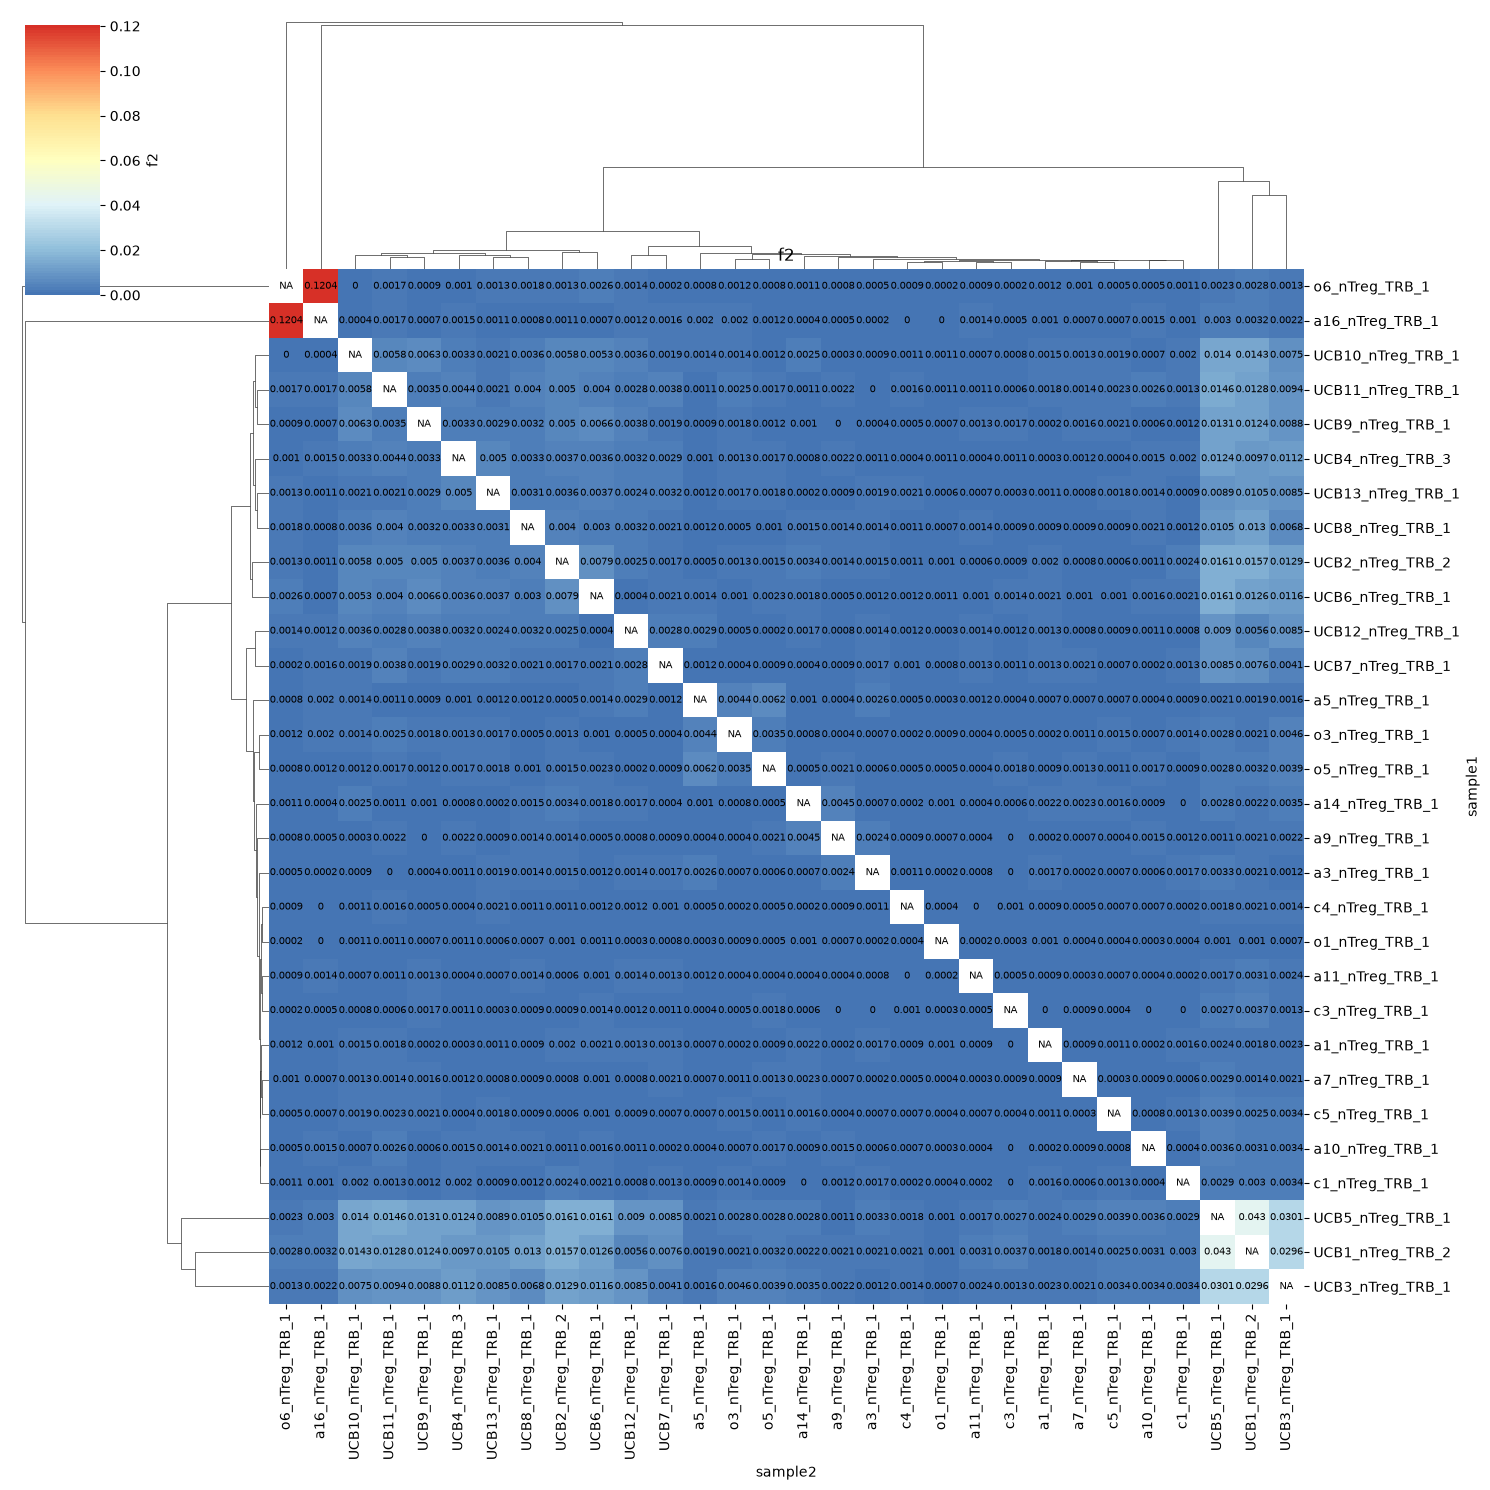

In [44]:
rsplot.beta_metric(beta_diversity,
                   metric="f2",
                   ignore_diagonal=True,
                   hclust=True,
                   log_values=False,
                   height = 15
                  )

### MDS for metric

In [45]:
ucb_treg_mds = beta.mds(beta_diversity)
ucb_treg_mds

,sample_id,MDS1,MDS2
0,UCB10_nTreg_TRB_1,-0.679864,1.047163
1,UCB11_nTreg_TRB_1,-0.561929,-0.103692
2,UCB12_nTreg_TRB_1,-0.174664,-0.069408
3,UCB13_nTreg_TRB_1,0.167571,0.205283
4,UCB1_nTreg_TRB_2,-0.295825,-0.011395
5,UCB2_nTreg_TRB_2,-0.082505,0.333433
6,UCB3_nTreg_TRB_1,-0.149031,-0.010438
7,UCB4_nTreg_TRB_3,-0.175081,0.051256
8,UCB5_nTreg_TRB_1,-0.295040,0.053254
9,UCB6_nTreg_TRB_1,-0.254590,0.230537


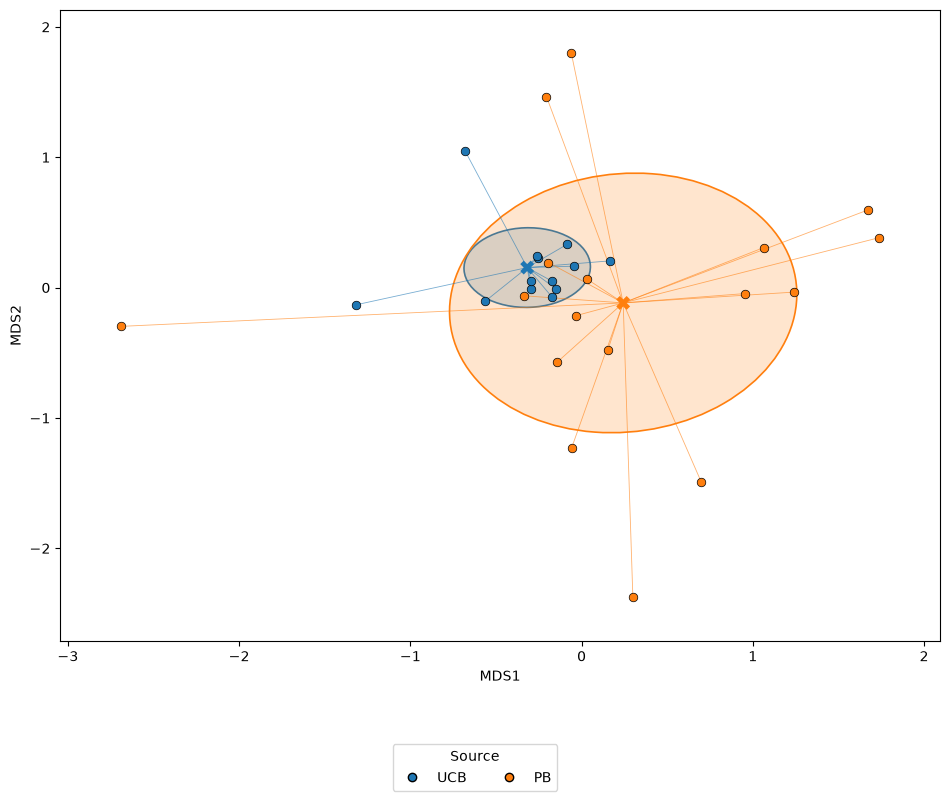

In [46]:
rsplot.beta_mds(ucb_treg_mds, metadata=metadata, group="source", centroids=True, dispersion=True, height=8)

## Clustering

### Create clusters

In [47]:
clusters = clustering.Clusters()
clusters

Clusters state:
  State: empty
Clonotypes: not read
Clusters: not created
Metadata: not added
Node Pgen: not calculated
ALICE: not calculated

In [48]:
clusters.read_from_clonosets_df(clonosets_treg, cl_filter=downsample_filter)

Pooled 117361 clonotypes from 30 samples


In [49]:
clusters.create_clusters(overlap_type='aaV', mismatches=1)

Nodes list created: 117361 nodes
Using all available worker processes by default. Set cpu=1 or another integer to change this.
Find neighbour clonotypes |##################################################| 694/694 tasks processed
found 55075 edges
-----------------------------
NexworkX graph created
Found 7479 clusters (2 or more nodes) and 86946 single nodes. Total: 94425


In [50]:
clusters.add_metadata(metadata)

In [51]:
clusters_df = clusters.as_dataframe()
clusters_df

,cluster_no,node_id,cdr3aa,v,j,cdr3nt,sample_id,freq,count,isotype,n_neighbours,experimental_group,donor_id,subset,source
0,0,15988,CASSLARVDNEQFF,TRBV5-1,TRBJ2-1,TGCGCCAGCAGCTTGGCCAGGGTGGACAATGAGCAGTTCTTC,UCB8_nTreg_TRB_1,0.000222,1,None,1,late,UCB8,nTreg,UCB
1,0,55564,CASSLDRGTDTQYF,TRBV5-1,TRBJ2-3,TGCGCCAGCAGCTTGGACAGGGGCACAGATACGCAGTATTTT,UCB5_nTreg_TRB_1,0.000222,1,None,11,preterm,UCB5,nTreg,UCB
2,0,70252,CASQLAGEYNEQFF,TRBV5-1,TRBJ2-1,TGCGCCAGCCAACTAGCGGGAGAGTACAATGAGCAGTTCTTC,UCB10_nTreg_TRB_1,0.000222,1,None,1,term,UCB10,nTreg,UCB
3,0,110338,CASSLDPNTDTQYF,TRBV5-1,TRBJ2-3,TGCGCCAGCAGCTTGGACCCGAACACAGATACGCAGTATTTT,c3_nTreg_TRB_1,0.000222,1,None,2,children,c3,nTreg,PB
4,0,67396,CASSLVAGTDTQYF,TRBV5-1,TRBJ2-3,TGCGCCAGCAGCTTGGTGGCTGGCACAGATACGCAGTATTTT,UCB4_nTreg_TRB_3,0.000222,1,None,8,late,UCB4,nTreg,UCB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117356,94420,16468,YASSHTDGGGNQPQHF,TRBV7-2,TRBJ1-5,TATGCCAGCAGCCATACCGACGGGGGGGGCAATCAGCCCCAGCATTTT,UCB8_nTreg_TRB_1,0.000222,1,None,0,late,UCB8,nTreg,UCB
117357,94421,61604,YASSPDRGSYEQYF,TRBV18,TRBJ2-7,TATGCCAGCTCACCAGACAGGGGCTCCTACGAGCAGTACTTC,UCB3_nTreg_TRB_1,0.000222,1,None,0,term,UCB3,nTreg,UCB
117358,94422,12222,YNTGELFF,TRBV7-3,TRBJ2-2,TACAACACCGGGGAGCTGTTTTTT,o3_nTreg_TRB_1,0.000444,2,None,0,older_adults,o3,nTreg,PB
117359,94423,8410,YSSGGCSGNTIYF,TRBV17,TRBJ1-3,TACAGTAGCGGTGGCTGCTCTGGAAACACCATATATTTT,UCB1_nTreg_TRB_2,0.000444,2,None,0,preterm,UCB1,nTreg,UCB


In [52]:
cluster_properties = clusters.properties()
cluster_properties

Using all available worker processes by default. Set cpu=1 or another integer to change this.
Calculating cluster properties |##################################################| 94425/94425 clusters processed


,cluster_no,cluster_id,nodes,edges,total_count,diameter,density,eccentricity,concensus_cdr3aa,concensus_cdr3nt,concensus_v,concensus_j
0,0,cluster_0,609,1972,737,27,0.010652,20.087028,CASSLGGGTDTQYF,TGCGCCAGCAGCTTGGGAGGGGGCACAGATACGCAGTACTTC,TRBV5-1,TRBJ2-3
1,1,cluster_1,586,2506,705,19,0.014620,15.358362,CASSLGGTYEQFF,TGCGCCAGCAGCTTGGGGGGCTCCTACGAGCAGTACTTC,TRBV5-1,TRBJ2-7
2,2,cluster_2,555,3716,702,14,0.024171,10.508108,CASSLGGYEQYF,TGCGCCAGCAGCTTGGGCGGAGATGAGCAGTACTTC,TRBV5-1,TRBJ2-7
3,3,cluster_3,419,2260,511,12,0.025808,9.715990,CASSLGGTDTQYF,TGCGCCAGCAGCTTGGGGGGCACAGATACGCAGTATTTT,TRBV5-1,TRBJ2-3
4,4,cluster_4,319,3013,399,14,0.059403,10.335423,CASSLGETQYF,TGCGCCAGCAGCTTGGCAGAGACGCAGTACTTC,TRBV5-1,TRBJ2-5
...,...,...,...,...,...,...,...,...,...,...,...,...
94420,94420,cluster_94420,1,0,1,0,0.000000,0.000000,YASSHTDGGGNQPQHF,TATGCCAGCAGCCATACCGACGGGGGGGGCAATCAGCCCCAGCATTTT,TRBV7-2,TRBJ1-5
94421,94421,cluster_94421,1,0,1,0,0.000000,0.000000,YASSPDRGSYEQYF,TATGCCAGCTCACCAGACAGGGGCTCCTACGAGCAGTACTTC,TRBV18,TRBJ2-7
94422,94422,cluster_94422,1,0,2,0,0.000000,0.000000,YNTGELFF,TACAACACCGGGGAGCTGTTTTTT,TRBV7-3,TRBJ2-2
94423,94423,cluster_94423,1,0,2,0,0.000000,0.000000,YSSGGCSGNTIYF,TACAGTAGCGGTGGCTGCTCTGGAAACACCATATATTTT,TRBV17,TRBJ1-3


In [53]:
cluster_properties.query("concensus_v != 'TRBV5-1' and concensus_j not in ['TRBJ2-7', 'TRBJ2-3', 'TRBJ1-2']")

,cluster_no,cluster_id,nodes,edges,total_count,diameter,density,eccentricity,concensus_cdr3aa,concensus_cdr3nt,concensus_v,concensus_j
21,21,cluster_21,120,286,132,16,0.040056,11.725000,CSARVTETQYF,TGCAGTGCTAGAGACAGAGAGACCCAGTACTTC,TRBV20-1,TRBJ2-5
22,22,cluster_22,114,274,138,12,0.042540,9.017544,CASSLTGNTEAFF,TGTGCCAGCAGTTTAAGGGGGAACACTGAAGCTTTCTTT,TRBV12-3,TRBJ1-1
24,24,cluster_24,104,357,118,11,0.066654,7.846154,CSARGGSNQPQHF,TGCAGTGCTAGAGGGGGGAGCAATCAGCCCCAGCATTTT,TRBV20-1,TRBJ1-5
25,25,cluster_25,98,335,113,9,0.070482,6.428571,CASSLGGNTEAFF,TGTGCCAGCAGCTTAGGGGGGAACACTGAAGCTTTCTTT,TRBV7-9,TRBJ1-1
26,26,cluster_26,95,389,106,13,0.087122,10.494737,CSARQETQYF,TGCAGTGCTAGAAAAGAGACCCAGTACTTC,TRBV20-1,TRBJ2-5
...,...,...,...,...,...,...,...,...,...,...,...,...
94417,94417,cluster_94417,1,0,1,0,0.000000,0.000000,WGPKKGEIGELFF,TGGGGTCCCAAGAAAGGGGAAATCGGGGAGCTGTTTTTT,TRBV10-3,TRBJ2-2
94418,94418,cluster_94418,1,0,3,0,0.000000,0.000000,WQAQGQPQHF,TGGCAGGCTCAGGGGCAGCCCCAGCATTTT,TRBV23-1,TRBJ1-5
94420,94420,cluster_94420,1,0,1,0,0.000000,0.000000,YASSHTDGGGNQPQHF,TATGCCAGCAGCCATACCGACGGGGGGGGCAATCAGCCCCAGCATTTT,TRBV7-2,TRBJ1-5
94422,94422,cluster_94422,1,0,2,0,0.000000,0.000000,YNTGELFF,TACAACACCGGGGAGCTGTTTTTT,TRBV7-3,TRBJ2-2


In [71]:
clusters

Clusters state:
  Completed: clonotypes read, clusters created, metadata added
Clonotypes:
    source: clonosets_df
    clonotypes: 117361
    samples: 30
    input_samples: 30
    filter:
      name: default_filter
      functionality: f
      downsample_size: 4500
      top: None
      by_umi: True
      mix_tails: False
      seed: 100
      count_threshold: None
      unweight: False
      recount_fractions: True
      white_list: []
      black_list: []
      pool_by: 
      convert: True
      ignore_small_clonosets: False
      retain_alleles: False
Graph: 117361 nodes and 55075 edges
Clusters: 7479 clusters (2 or more nodes) and 86946 single nodes. Total: 94425
Clustering parameters:
    method: mismatches
    overlap_type: aaV
    mismatches: 1
Metadata columns: experimental_group, donor_id, subset, source
Node Pgen: not calculated
ALICE: not calculated

### Plot clusters

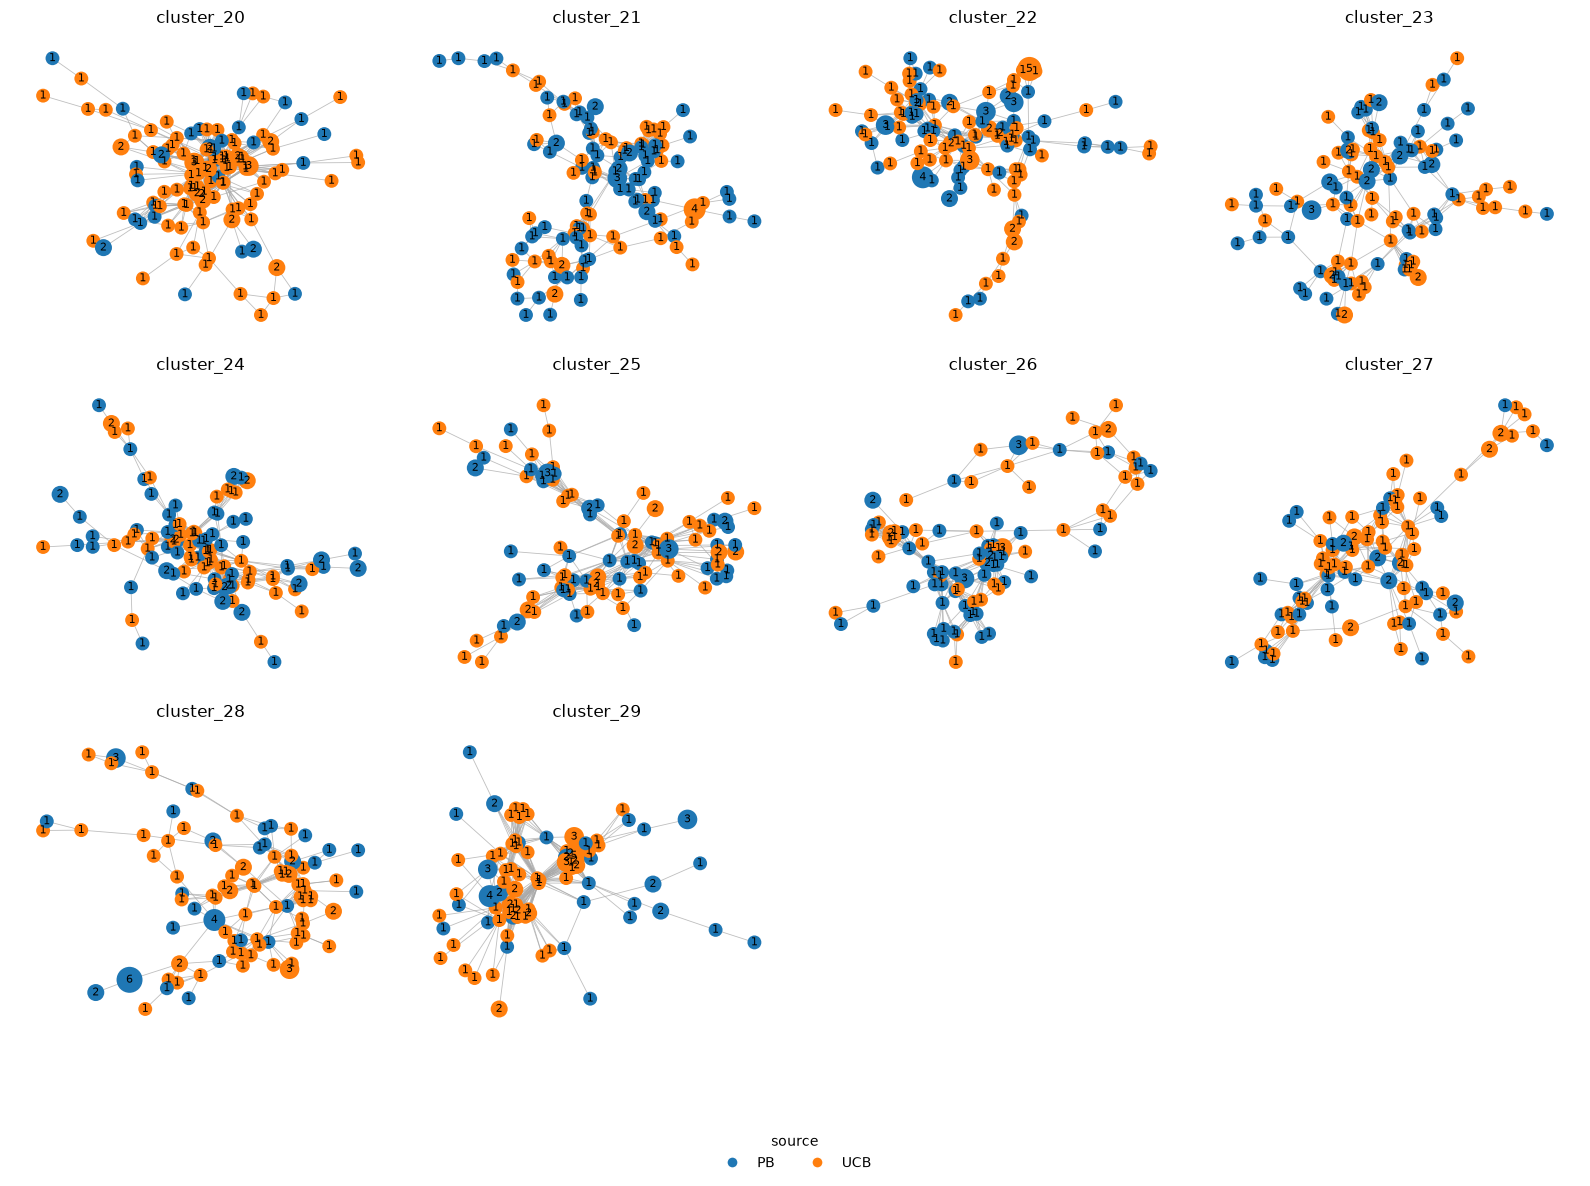

In [54]:
clusters.plot_cluster(range(20,30), color="source", label="count", log_scaled=False, size="count", linear_scale=50)